# Netflix Movies and TV Shows EDA

## Project Introduction

This notebook presents a professional Exploratory Data Analysis (EDA) of the Netflix Movies and TV Shows dataset from Kaggle. The analysis investigates Netflix's content catalog across content type, time, geography, genre, ratings, duration, directors, and cast.

The goal is to convert raw entertainment catalog data into clear business insights that can support content strategy, regional planning, audience targeting, and portfolio decisions.

## Business Objective

Netflix operates in a highly competitive streaming market where content breadth, regional relevance, genre mix, and audience suitability are central to user acquisition and retention.

This EDA answers the following business questions:

- What proportion of the catalog is Movies vs TV Shows?
- How has Netflix content grown over time?
- Which countries contribute the most content?
- Which genres dominate the platform?
- What ratings are most common across Movies and TV Shows?
- How long are movies and how many seasons do TV Shows usually have?
- Which directors and actors appear most frequently?
- What actionable recommendations can be made from these patterns?

## Data Loading

In [21]:
# Import core data analysis and visualization libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")

# Professional visualization defaults
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["figure.dpi"] = 120

# Reusable project styling
BRAND_COLORS = {
    "red": "#E50914",
    "black": "#221F1F",
    "gray": "#6B7280",
    "blue": "#2F6B9A",
    "green": "#2CA58D",
    "orange": "#F58518",
}


def polish_chart(title, xlabel=None, ylabel=None, rotate_x=False):
    # Apply consistent labels, gridlines, and spacing to charts.
    plt.title(title, fontsize=16, fontweight="bold", pad=14)
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    if rotate_x:
        plt.xticks(rotation=45, ha="right")
    sns.despine(left=False, bottom=False)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()


def add_bar_labels(ax, fmt="{:,.0f}"):
    # Add readable labels to vertical bar charts.
    for container in ax.containers:
        labels = [fmt.format(value) for value in container.datavalues]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)


# Create output folder for saved charts
IMAGE_DIR = Path.cwd().parent / "images"
IMAGE_DIR.mkdir(exist_ok=True)

In [3]:
# importing data
current_dir = Path.cwd()

data_path = current_dir.parent / "data" / "netflix_titles.csv"

df = pd.read_csv(data_path)

print(f"Dataset loaded successfully from: {data_path}")

Dataset loaded successfully from: d:\Data analysis\Project_1_Netfilx\data\netflix_titles.csv


## Data Understanding

In [4]:
# Display the first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Dataset shape and column names
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print("\nColumn names:")
print(df.columns.tolist())

Rows: 8,807
Columns: 12

Column names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [6]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
# Summary statistics for numeric and categorical columns
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Dick Johnson Is Dead,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,6173,4528,Rajiv Chilaka,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,7982,7692,David Attenborough,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,7976,748,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8797,1767,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8803,17,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8804,220,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_count,missing_percentage
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


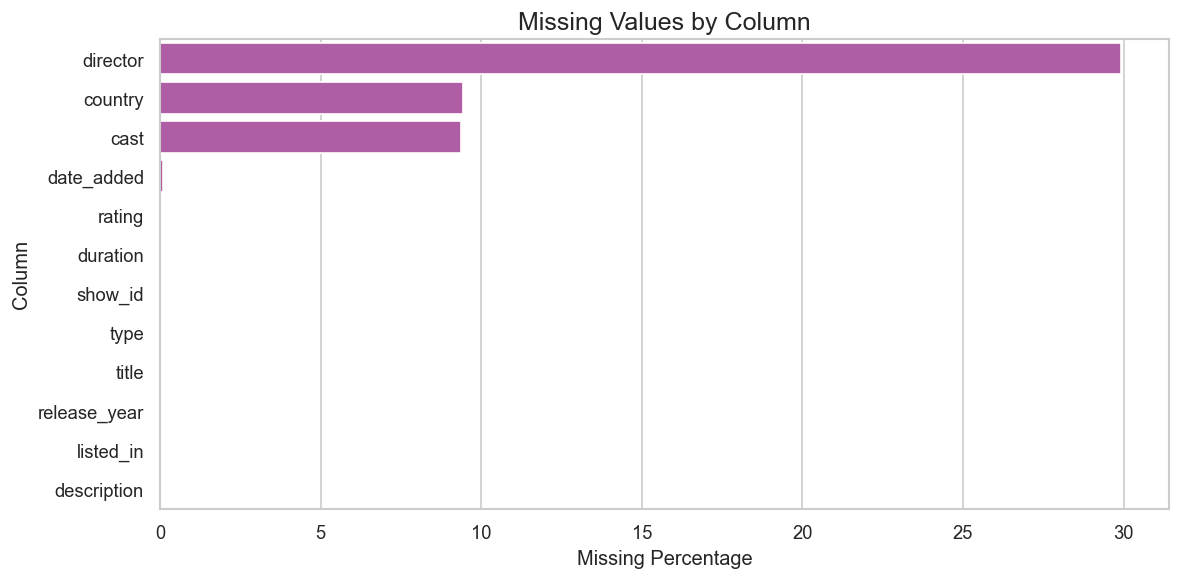

In [8]:
# Missing values analysis
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_percentage=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)

display(missing_summary)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=missing_summary.reset_index(),
    x="missing_percentage",
    y="index",
    color="#BD4FAF",
)
plt.title("Missing Values by Column")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [9]:
display(Markdown(f'''
**Data Understanding Insights**

- The dataset contains **{df.shape[0]:,} titles** and **{df.shape[1]} columns**.
- Missing-value checks identify which fields need cleaning before analysis.
- Text-heavy columns such as director, cast, and country commonly require careful handling because missing values often mean unavailable metadata rather than true zero values.

**Business implication:** Metadata completeness affects search, recommendation quality, geographic analysis, and talent-level insights. Columns with high missingness should be interpreted carefully.
'''))


**Data Understanding Insights**

- The dataset contains **8,807 titles** and **12 columns**.
- Missing-value checks identify which fields need cleaning before analysis.
- Text-heavy columns such as director, cast, and country commonly require careful handling because missing values often mean unavailable metadata rather than true zero values.

**Business implication:** Metadata completeness affects search, recommendation quality, geographic analysis, and talent-level insights. Columns with high missingness should be interpreted carefully.


## Data Cleaning

In [10]:
# Work on a copy to preserve the raw dataframe
netflix = df.copy()

# Standardize column names just in case whitespace exists
netflix.columns = netflix.columns.str.strip()

# Remove exact duplicate rows
duplicate_count = netflix.duplicated().sum()
netflix = netflix.drop_duplicates()
print(f"Duplicate rows removed: {duplicate_count}")

Duplicate rows removed: 0


In [11]:
# Fill missing categorical text fields with clear labels
fill_values = {
    "director": "Unknown Director",
    "cast": "Unknown Cast",
    "country": "Unknown Country",
    "rating": "Unknown Rating",
    "duration": "Unknown Duration",
}

netflix = netflix.fillna(fill_values)

# date_added is analytically important, so convert it to datetime
netflix["date_added"] = pd.to_datetime(netflix["date_added"], errors="coerce")

# Extract useful time features
netflix["year_added"] = netflix["date_added"].dt.year
netflix["month_added"] = netflix["date_added"].dt.month
netflix["month_name_added"] = netflix["date_added"].dt.month_name()

# Release year as numeric
netflix["release_year"] = pd.to_numeric(netflix["release_year"], errors="coerce")

In [12]:
# Separate duration into value and unit
duration_parts = netflix["duration"].astype(str).str.extract(r"(\d+)\s*(\D+)")
netflix["duration_value"] = pd.to_numeric(duration_parts[0], errors="coerce")
netflix["duration_unit"] = duration_parts[1].str.strip()

# Create clean list versions for multi-value columns
netflix["country_clean"] = netflix["country"].apply(
    lambda value: [item.strip() for item in str(value).split(",") if item.strip()]
)
netflix["genre_clean"] = netflix["listed_in"].apply(
    lambda value: [item.strip() for item in str(value).split(",") if item.strip()]
)

# Create primary country and primary genre for simpler grouped analysis
netflix["primary_country"] = netflix["country_clean"].apply(lambda values: values[0] if values else "Unknown Country")
netflix["primary_genre"] = netflix["genre_clean"].apply(lambda values: values[0] if values else "Unknown Genre")

# Age of content when added to Netflix
netflix["content_age_when_added"] = netflix["year_added"] - netflix["release_year"]

netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,year_added,month_added,month_name_added,duration_value,duration_unit,country_clean,genre_clean,primary_country,primary_genre,content_age_when_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,...,2021.0,9.0,September,90.0,min,[United States],[Documentaries],United States,Documentaries,1.0
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,September,2.0,Seasons,[South Africa],"[International TV Shows, TV Dramas, TV Mysteries]",South Africa,International TV Shows,0.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown Country,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,September,1.0,Season,[Unknown Country],"[Crime TV Shows, International TV Shows, TV Ac...",Unknown Country,Crime TV Shows,0.0
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Cast,Unknown Country,2021-09-24,2021,TV-MA,1 Season,...,2021.0,9.0,September,1.0,Season,[Unknown Country],"[Docuseries, Reality TV]",Unknown Country,Docuseries,0.0
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,...,2021.0,9.0,September,2.0,Seasons,[India],"[International TV Shows, Romantic TV Shows, TV...",India,International TV Shows,0.0


In [13]:
for col in netflix.columns:
    if netflix[col].apply(lambda x: isinstance(x, list)).any():
        print(col)



country_clean
genre_clean


In [14]:
# Verify cleaned dataset
cleaning_summary = pd.DataFrame({
    "rows_after_cleaning": [len(netflix)],
    "columns_after_cleaning": [netflix.shape[1]],
    "remaining_duplicates": [netflix.drop(columns=["country_clean", "genre_clean"]).duplicated().sum()], # dropping the columns because they are lists
    "missing_date_added": [netflix["date_added"].isna().sum()],
})

display(cleaning_summary)
display(netflix[["type", "title", "date_added", "year_added", "month_added", "duration", "duration_value", "duration_unit", "primary_country", "primary_genre"]].head())

,rows_after_cleaning,columns_after_cleaning,remaining_duplicates,missing_date_added
0,8807,22,0,98


,type,title,date_added,year_added,month_added,duration,duration_value,duration_unit,primary_country,primary_genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2021.0,9.0,90 min,90.0,min,United States,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021.0,9.0,2 Seasons,2.0,Seasons,South Africa,International TV Shows
2,TV Show,Ganglands,2021-09-24,2021.0,9.0,1 Season,1.0,Season,Unknown Country,Crime TV Shows
3,TV Show,Jailbirds New Orleans,2021-09-24,2021.0,9.0,1 Season,1.0,Season,Unknown Country,Docuseries
4,TV Show,Kota Factory,2021-09-24,2021.0,9.0,2 Seasons,2.0,Seasons,India,International TV Shows


In [15]:
display(Markdown(f'''
**Data Cleaning Insights**

- Removed **{duplicate_count:,} duplicate rows**.
- Converted `date_added` into a datetime field and extracted `year_added` and `month_added`.
- Split `duration` into numeric and categorical components so Movies and TV Shows can be analyzed separately.
- Created clean list-based country and genre columns to support multi-label analysis.

**Business implication:** Clean time, geography, genre, and duration fields make the catalog easier to analyze for acquisition trends, market coverage, and audience segmentation.
'''))


**Data Cleaning Insights**

- Removed **0 duplicate rows**.
- Converted `date_added` into a datetime field and extracted `year_added` and `month_added`.
- Split `duration` into numeric and categorical components so Movies and TV Shows can be analyzed separately.
- Created clean list-based country and genre columns to support multi-label analysis.

**Business implication:** Clean time, geography, genre, and duration fields make the catalog easier to analyze for acquisition trends, market coverage, and audience segmentation.


## Feature Engineering

Strong EDA is more useful when raw columns are converted into business-ready features. This section creates additional variables for catalog age, release era, audience maturity, international availability, and metadata quality.

In [16]:
# Feature engineering for advanced analysis
latest_release_year = int(netflix["release_year"].max())

netflix["content_age"] = latest_release_year - netflix["release_year"]
netflix["is_recent_release"] = netflix["release_year"] >= (latest_release_year - 5)
netflix["is_classic_title"] = netflix["release_year"] < 2000
netflix["is_international"] = netflix["country_clean"].apply(lambda values: len([v for v in values if v != "Unknown Country"]) > 1)
netflix["genre_count"] = netflix["genre_clean"].apply(len)
netflix["country_count"] = netflix["country_clean"].apply(lambda values: len([v for v in values if v != "Unknown Country"]))
netflix["cast_count"] = netflix["cast"].apply(lambda value: 0 if value == "Unknown Cast" else len([item for item in str(value).split(",") if item.strip()]))
netflix["director_count"] = netflix["director"].apply(lambda value: 0 if value == "Unknown Director" else len([item for item in str(value).split(",") if item.strip()]))
netflix["has_director"] = netflix["director"].ne("Unknown Director")
netflix["has_cast"] = netflix["cast"].ne("Unknown Cast")
netflix["has_country"] = netflix["country"].ne("Unknown Country")

# Release era buckets support clean portfolio segmentation
netflix["release_era"] = pd.cut(
    netflix["release_year"],
    bins=[1900, 1979, 1989, 1999, 2009, 2015, latest_release_year],
    labels=["Pre-1980", "1980s", "1990s", "2000s", "2010-2015", "2016+"],
    include_lowest=True,
)

# Audience maturity segments based on common US-style Netflix ratings
maturity_map = {
    "G": "Kids/Family",
    "TV-Y": "Kids/Family",
    "TV-G": "Kids/Family",
    "PG": "Family/Teen",
    "TV-Y7": "Family/Teen",
    "TV-Y7-FV": "Family/Teen",
    "TV-PG": "Family/Teen",
    "PG-13": "Teen",
    "TV-14": "Teen",
    "R": "Mature",
    "NC-17": "Mature",
    "TV-MA": "Mature",
    "NR": "Unrated/Other",
    "UR": "Unrated/Other",
    "Unknown Rating": "Unrated/Other",
}
netflix["maturity_segment"] = netflix["rating"].map(maturity_map).fillna("Unrated/Other")

# Add timing flags for release planning analysis
netflix["added_quarter"] = netflix["date_added"].dt.quarter
netflix["added_season"] = netflix["month_added"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall",
})

feature_preview_cols = [
    "title", "type", "release_year", "content_age", "release_era",
    "maturity_segment", "genre_count", "country_count", "is_international",
    "cast_count", "director_count", "added_quarter", "added_season",
]
display(netflix[feature_preview_cols].head())

,title,type,release_year,content_age,release_era,maturity_segment,genre_count,country_count,is_international,cast_count,director_count,added_quarter,added_season
0,Dick Johnson Is Dead,Movie,2020,1,2016+,Teen,1,1,False,0,1,3.0,Fall
1,Blood & Water,TV Show,2021,0,2016+,Mature,3,1,False,19,0,3.0,Fall
2,Ganglands,TV Show,2021,0,2016+,Mature,3,0,False,9,1,3.0,Fall
3,Jailbirds New Orleans,TV Show,2021,0,2016+,Mature,2,0,False,0,0,3.0,Fall
4,Kota Factory,TV Show,2021,0,2016+,Mature,3,1,False,8,0,3.0,Fall


In [17]:
engineered_summary = pd.DataFrame({
    "metric": [
        "Latest release year",
        "Recent release share",
        "Classic title share",
        "International/co-production share",
        "Average genres per title",
        "Average cast members listed",
        "Director metadata coverage",
        "Cast metadata coverage",
        "Country metadata coverage",
    ],
    "value": [
        latest_release_year,
        f"{netflix['is_recent_release'].mean() * 100:.1f}%",
        f"{netflix['is_classic_title'].mean() * 100:.1f}%",
        f"{netflix['is_international'].mean() * 100:.1f}%",
        f"{netflix['genre_count'].mean():.2f}",
        f"{netflix['cast_count'].mean():.2f}",
        f"{netflix['has_director'].mean() * 100:.1f}%",
        f"{netflix['has_cast'].mean() * 100:.1f}%",
        f"{netflix['has_country'].mean() * 100:.1f}%",
    ],
})

display(engineered_summary)

,metric,value
0,Latest release year,2021
1,Recent release share,64.2%
2,Classic title share,6.0%
3,International/co-production share,14.9%
4,Average genres per title,2.19
5,Average cast members listed,7.28
6,Director metadata coverage,70.1%
7,Cast metadata coverage,90.6%
8,Country metadata coverage,90.6%


In [18]:
display(Markdown(f'''
**Feature Engineering Insights**

- The dataset now includes **recency, catalog age, maturity, geography, genre breadth, and metadata completeness** features.
- **{netflix['is_recent_release'].mean() * 100:.1f}%** of titles are recent releases based on the latest release year in the dataset.
- **{netflix['is_international'].mean() * 100:.1f}%** of titles list multiple countries, indicating international collaboration or distribution metadata.

**Business implication:** These engineered features make it easier to evaluate catalog freshness, international reach, audience targeting, and metadata quality at portfolio level.
'''))


**Feature Engineering Insights**

- The dataset now includes **recency, catalog age, maturity, geography, genre breadth, and metadata completeness** features.
- **64.2%** of titles are recent releases based on the latest release year in the dataset.
- **14.9%** of titles list multiple countries, indicating international collaboration or distribution metadata.

**Business implication:** These engineered features make it easier to evaluate catalog freshness, international reach, audience targeting, and metadata quality at portfolio level.


## Exploratory Data Analysis

### A. General Analysis

In [19]:
total_titles = len(netflix)
type_counts = netflix["type"].value_counts()
type_percentages = (type_counts / total_titles * 100).round(2)

display(pd.DataFrame({"count": type_counts, "percentage": type_percentages}))
print(f"Total number of titles: {total_titles:,}")

,count,percentage
type,,
Movie,6131,69.62
TV Show,2676,30.38


Total number of titles: 8,807


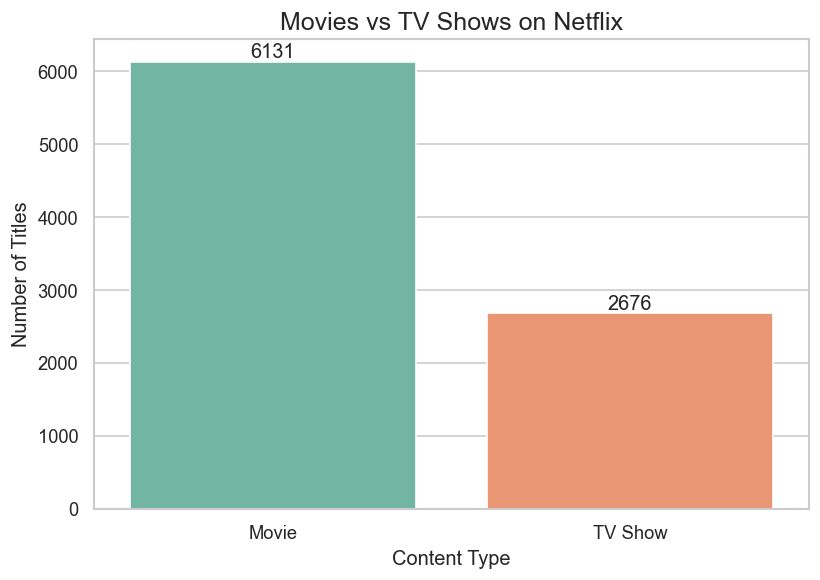

In [22]:
# Movies vs TV Shows count plot
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=netflix, x="type", order=type_counts.index, palette="Set2")
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "movie_vs_tvshow.png", bbox_inches="tight")
plt.show()

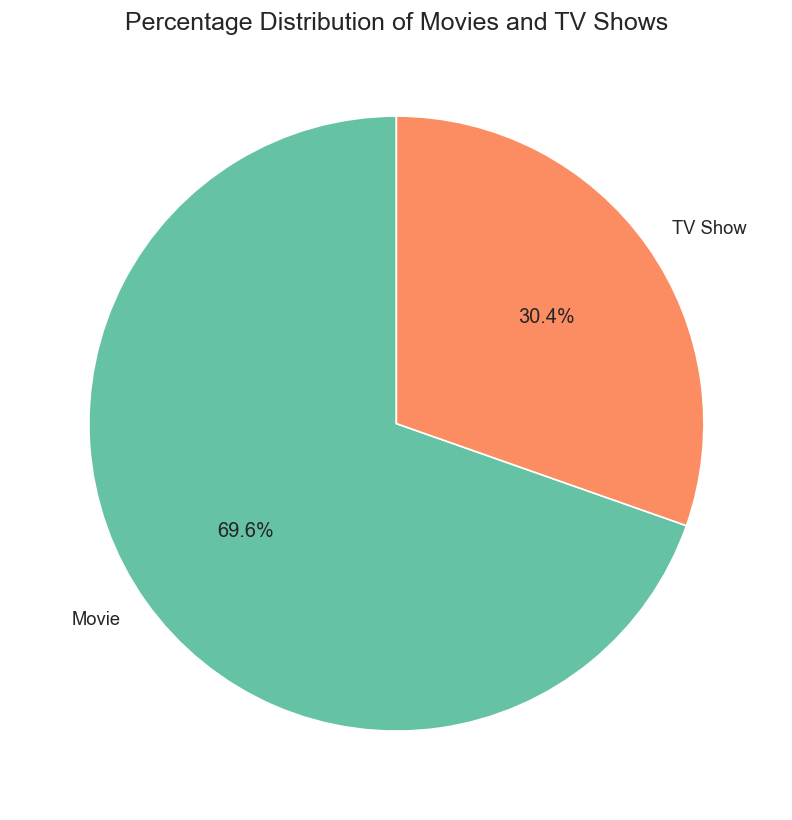

In [23]:
# Percentage distribution pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", len(type_counts)),
)
plt.title("Percentage Distribution of Movies and TV Shows")
plt.tight_layout()
plt.show()

In [24]:
dominant_type = type_counts.idxmax()
dominant_pct = type_percentages.loc[dominant_type]

display(Markdown(f'''
**General Analysis Insights**

- The catalog contains **{total_titles:,} total titles**.
- **{dominant_type}** are the dominant content type, representing **{dominant_pct:.2f}%** of the catalog.
- The balance between Movies and TV Shows indicates whether Netflix's catalog leans toward shorter one-time viewing or longer episodic engagement.

**Business implication:** A movie-heavy catalog can support variety and frequent browsing, while a stronger TV catalog can improve retention through multi-episode viewing.
'''))


**General Analysis Insights**

- The catalog contains **8,807 total titles**.
- **Movie** are the dominant content type, representing **69.62%** of the catalog.
- The balance between Movies and TV Shows indicates whether Netflix's catalog leans toward shorter one-time viewing or longer episodic engagement.

**Business implication:** A movie-heavy catalog can support variety and frequent browsing, while a stronger TV catalog can improve retention through multi-episode viewing.


### B. Time Analysis

In [25]:
content_by_year = netflix.dropna(subset=["year_added"]).groupby("year_added").size()
content_by_month = netflix.dropna(subset=["month_added"]).groupby("month_added").size()
release_year_distribution = netflix.dropna(subset=["release_year"]).groupby("release_year").size()

display(content_by_year.tail(10).to_frame("titles_added"))

,titles_added
year_added,
2012.0,3
2013.0,10
2014.0,23
2015.0,73
2016.0,418
2017.0,1164
2018.0,1625
2019.0,1999
2020.0,1878


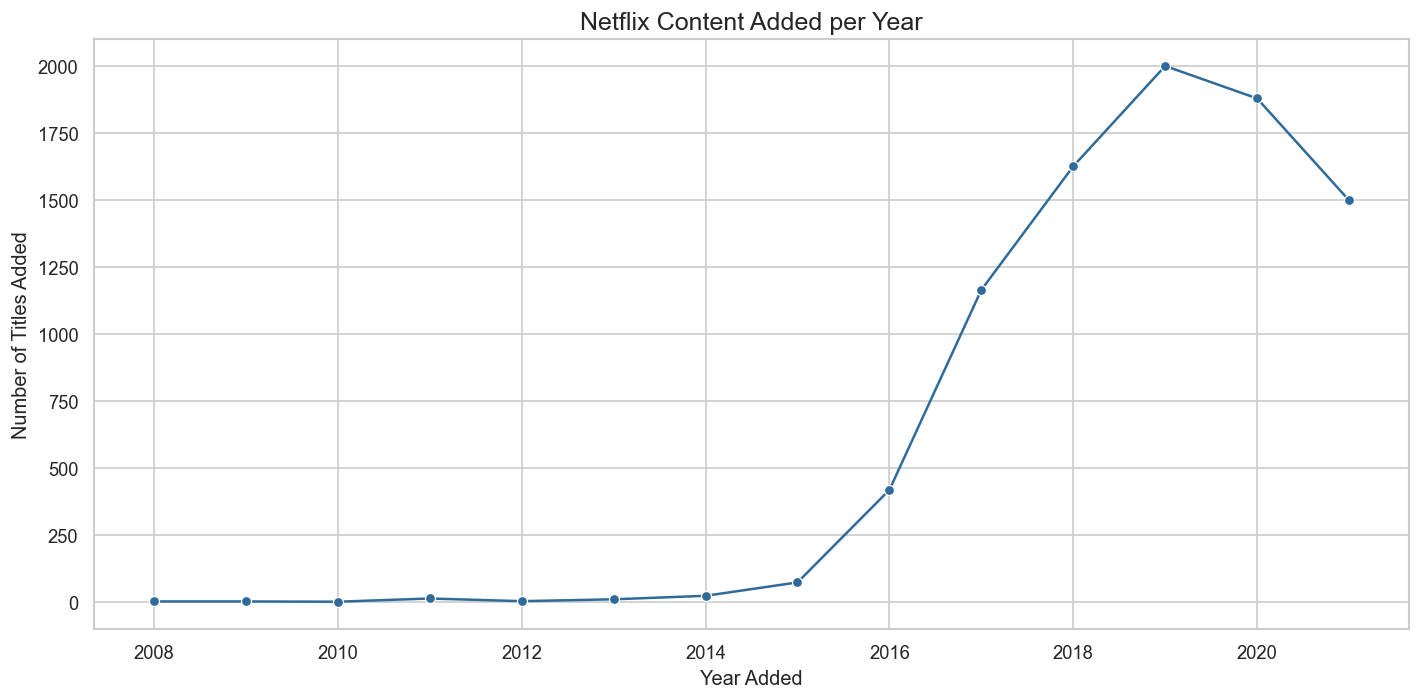

In [26]:
# Content added per year and growth over time
plt.figure(figsize=(12, 6))
sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker="o", color="#2F6B9A")
plt.title("Netflix Content Added per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "content_growth.png", bbox_inches="tight")
plt.show()

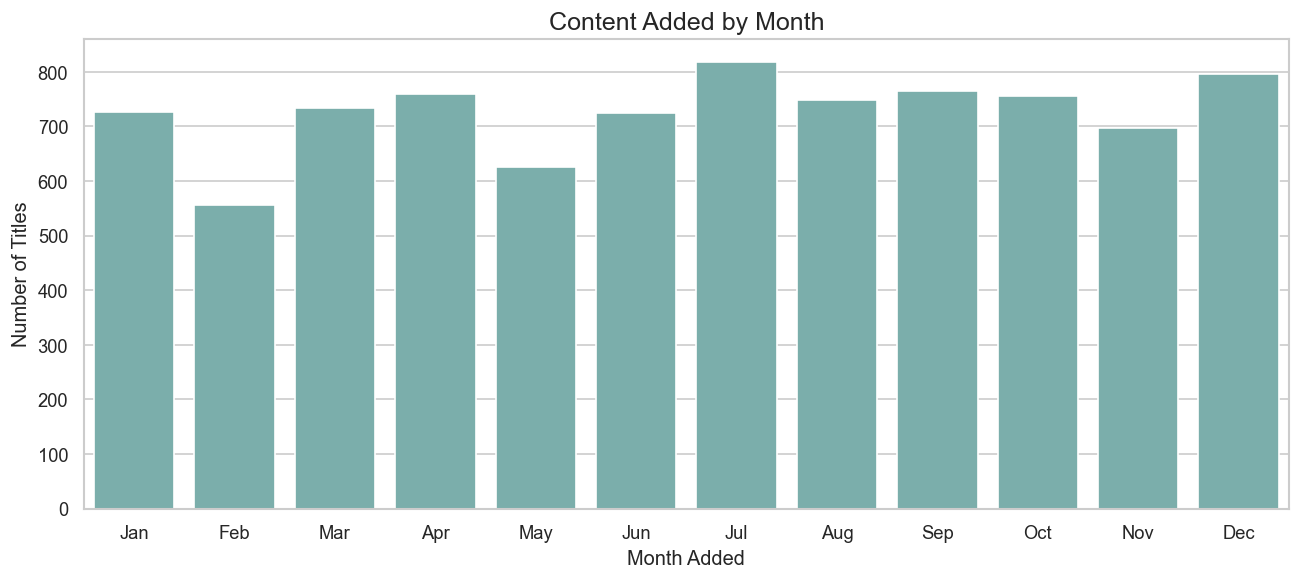

In [27]:
# Content added per month
month_order = list(range(1, 13))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(11, 5))
sns.barplot(x=month_order, y=[content_by_month.get(m, 0) for m in month_order], color="#72B7B2")
plt.xticks(ticks=range(12), labels=month_labels)
plt.title("Content Added by Month")
plt.xlabel("Month Added")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

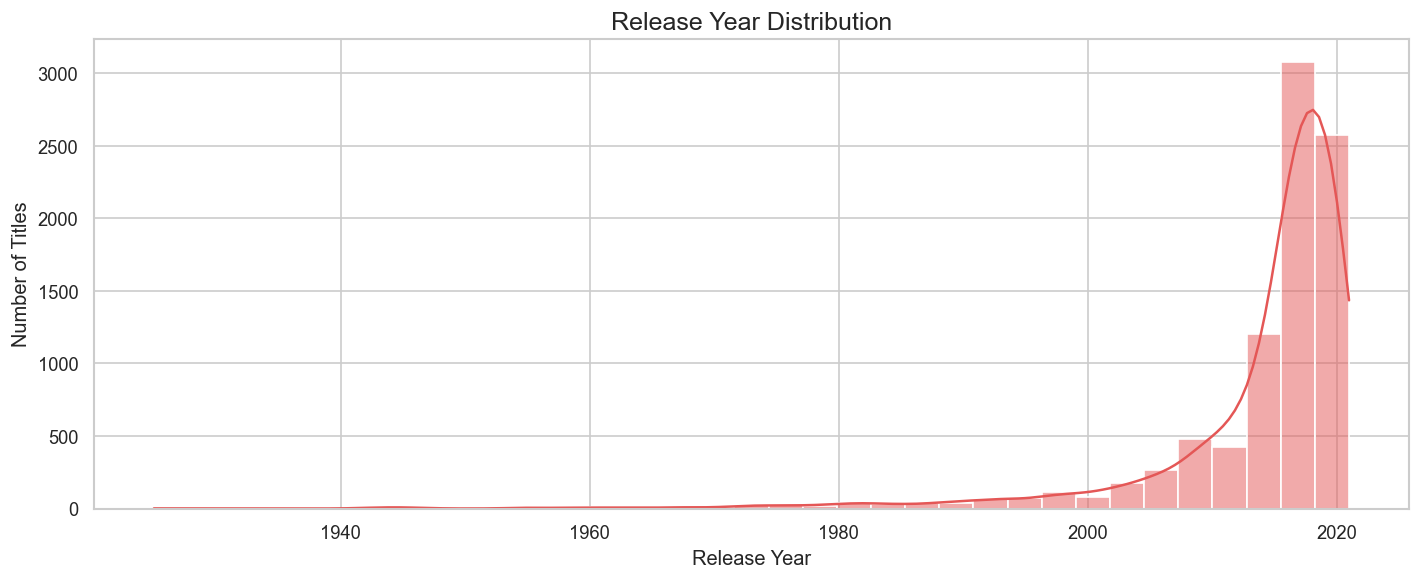

In [28]:
# Release year distribution
plt.figure(figsize=(12, 5))
sns.histplot(data=netflix, x="release_year", bins=35, kde=True, color="#E45756")
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

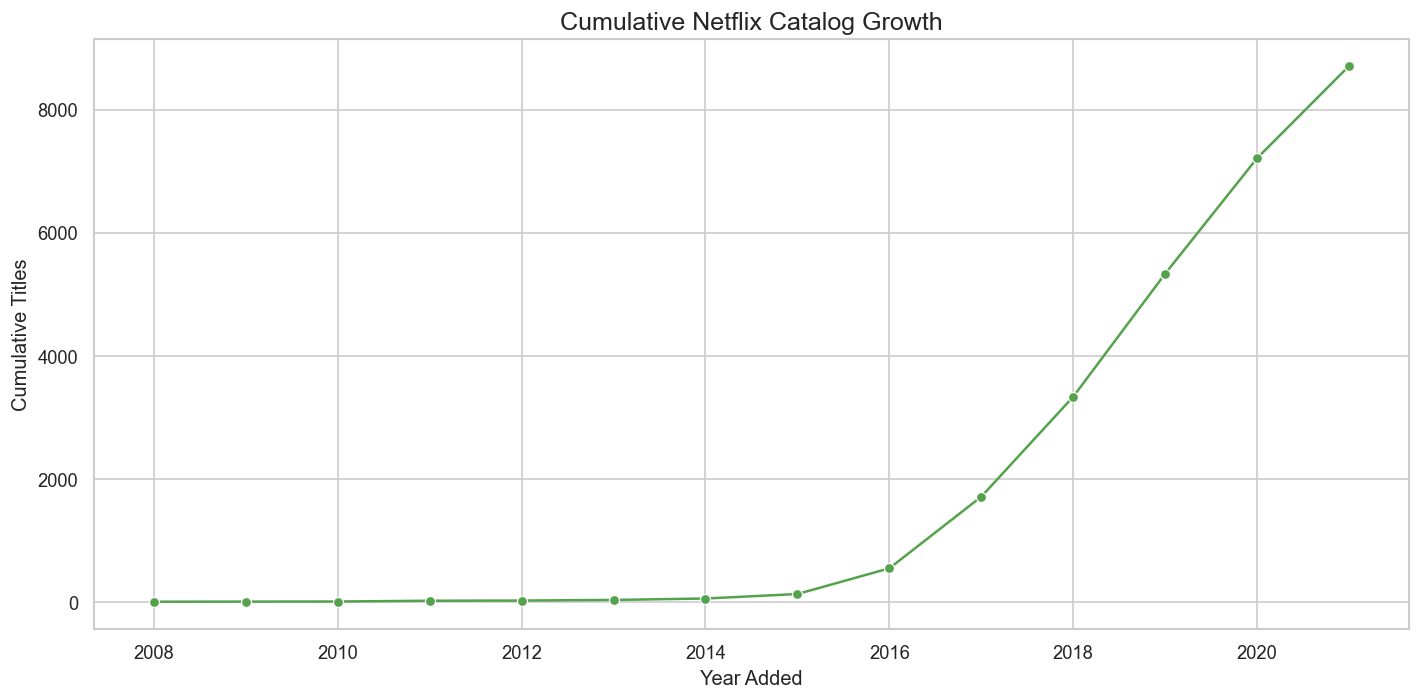

In [29]:
# Cumulative content growth
cumulative_growth = content_by_year.cumsum()

plt.figure(figsize=(12, 6))
sns.lineplot(x=cumulative_growth.index, y=cumulative_growth.values, marker="o", color="#54A24B")
plt.title("Cumulative Netflix Catalog Growth")
plt.xlabel("Year Added")
plt.ylabel("Cumulative Titles")
plt.tight_layout()
plt.show()

In [30]:
peak_year = int(content_by_year.idxmax())
peak_year_count = int(content_by_year.max())
peak_month = int(content_by_month.idxmax())
peak_month_name = pd.Timestamp(2024, peak_month, 1).month_name()

display(Markdown(f'''
**Time Analysis Insights**

- The highest content-addition year was **{peak_year}**, with **{peak_year_count:,} titles** added.
- The most active calendar month for additions was **{peak_month_name}**.
- Cumulative growth shows how aggressively Netflix expanded its catalog over time.

**Business implication:** Understanding addition patterns helps identify acquisition cycles, release calendar strategy, and periods of catalog acceleration or slowdown.
'''))


**Time Analysis Insights**

- The highest content-addition year was **2019**, with **1,999 titles** added.
- The most active calendar month for additions was **July**.
- Cumulative growth shows how aggressively Netflix expanded its catalog over time.

**Business implication:** Understanding addition patterns helps identify acquisition cycles, release calendar strategy, and periods of catalog acceleration or slowdown.


### C. Country Analysis

In [31]:
# Explode country lists so multi-country titles are counted properly
country_exploded = netflix.explode("country_clean").rename(columns={"country_clean": "country_name"})
country_exploded = country_exploded[country_exploded["country_name"].ne("Unknown Country")]

top_countries = country_exploded["country_name"].value_counts().head(10)
display(top_countries.to_frame("title_count"))

,title_count
country_name,
United States,3690
India,1046
United Kingdom,806
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


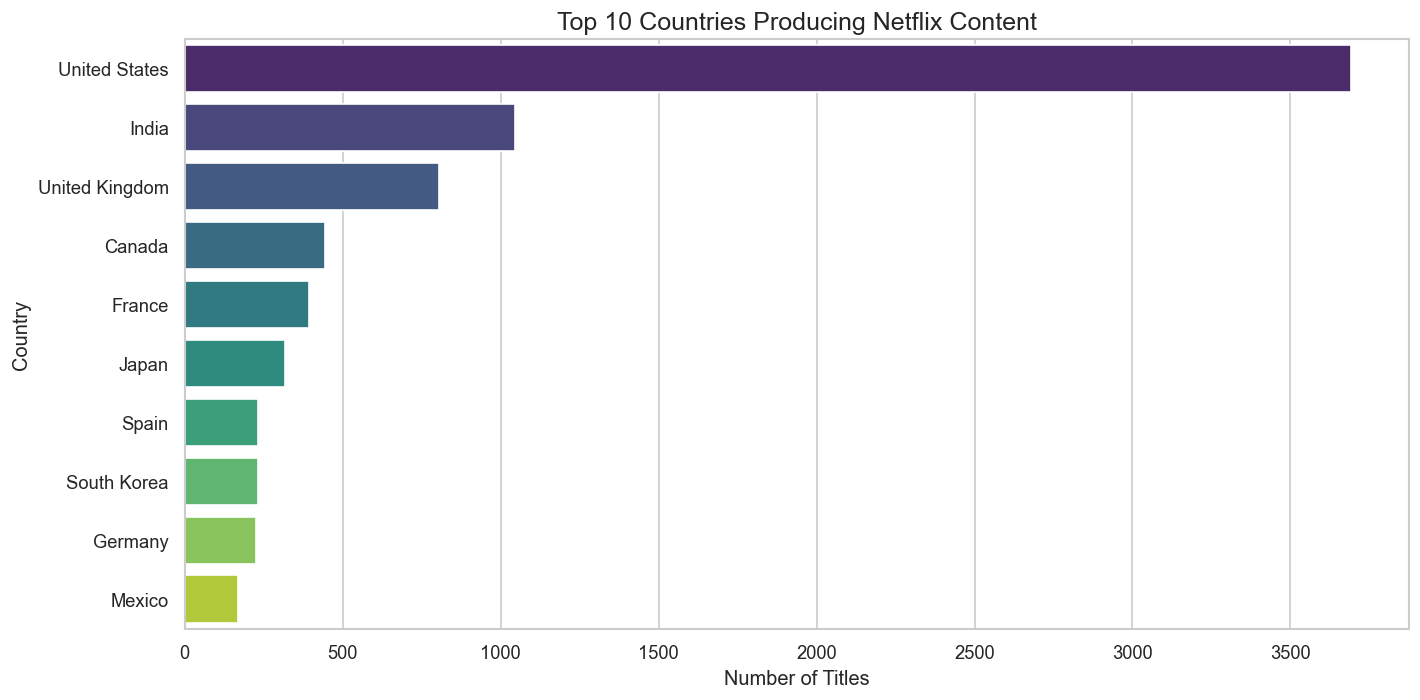

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "top_countries.png", bbox_inches="tight")
plt.show()

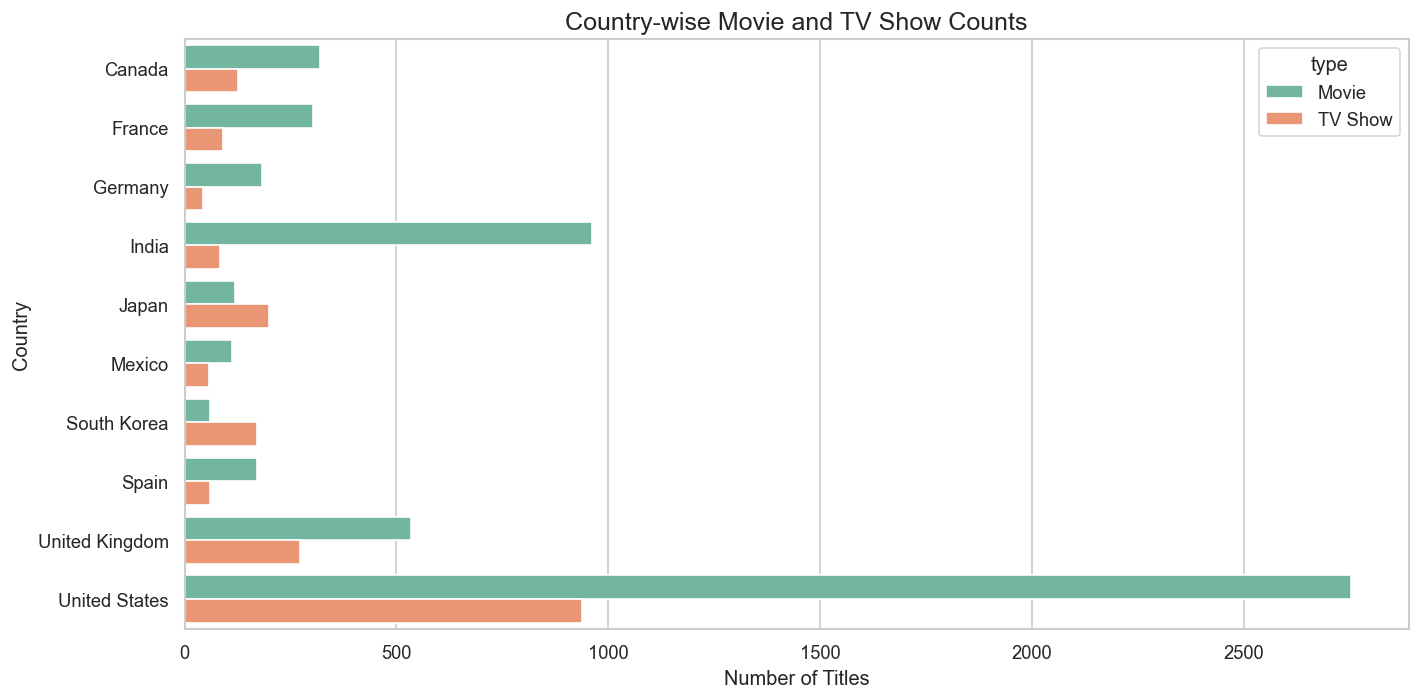

In [33]:
country_type_counts = (
    country_exploded.groupby(["country_name", "type"])
    .size()
    .reset_index(name="count")
)

top_country_names = top_countries.index.tolist()
country_type_top = country_type_counts[country_type_counts["country_name"].isin(top_country_names)]

plt.figure(figsize=(12, 6))
sns.barplot(data=country_type_top, x="count", y="country_name", hue="type", palette="Set2")
plt.title("Country-wise Movie and TV Show Counts")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [34]:
top_country = top_countries.index[0]
top_country_count = int(top_countries.iloc[0])

display(Markdown(f'''
**Country Analysis Insights**

- **{top_country}** contributes the largest number of titles, with **{top_country_count:,} appearances** in the country metadata.
- Comparing Movies and TV Shows by country highlights which markets are stronger in film versus episodic production.
- Multi-country titles are counted for each listed country, which better reflects international co-productions.

**Business implication:** Country-level patterns can guide regional licensing, localization, dubbing/subtitling priorities, and market-specific content investment.
'''))


**Country Analysis Insights**

- **United States** contributes the largest number of titles, with **3,690 appearances** in the country metadata.
- Comparing Movies and TV Shows by country highlights which markets are stronger in film versus episodic production.
- Multi-country titles are counted for each listed country, which better reflects international co-productions.

**Business implication:** Country-level patterns can guide regional licensing, localization, dubbing/subtitling priorities, and market-specific content investment.


### D. Genre Analysis

In [35]:
# Explode genre lists for multi-label genre analysis
genre_exploded = netflix.explode("genre_clean").rename(columns={"genre_clean": "genre"})
top_genres = genre_exploded["genre"].value_counts().head(20)
display(top_genres.to_frame("title_count"))

,title_count
genre,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


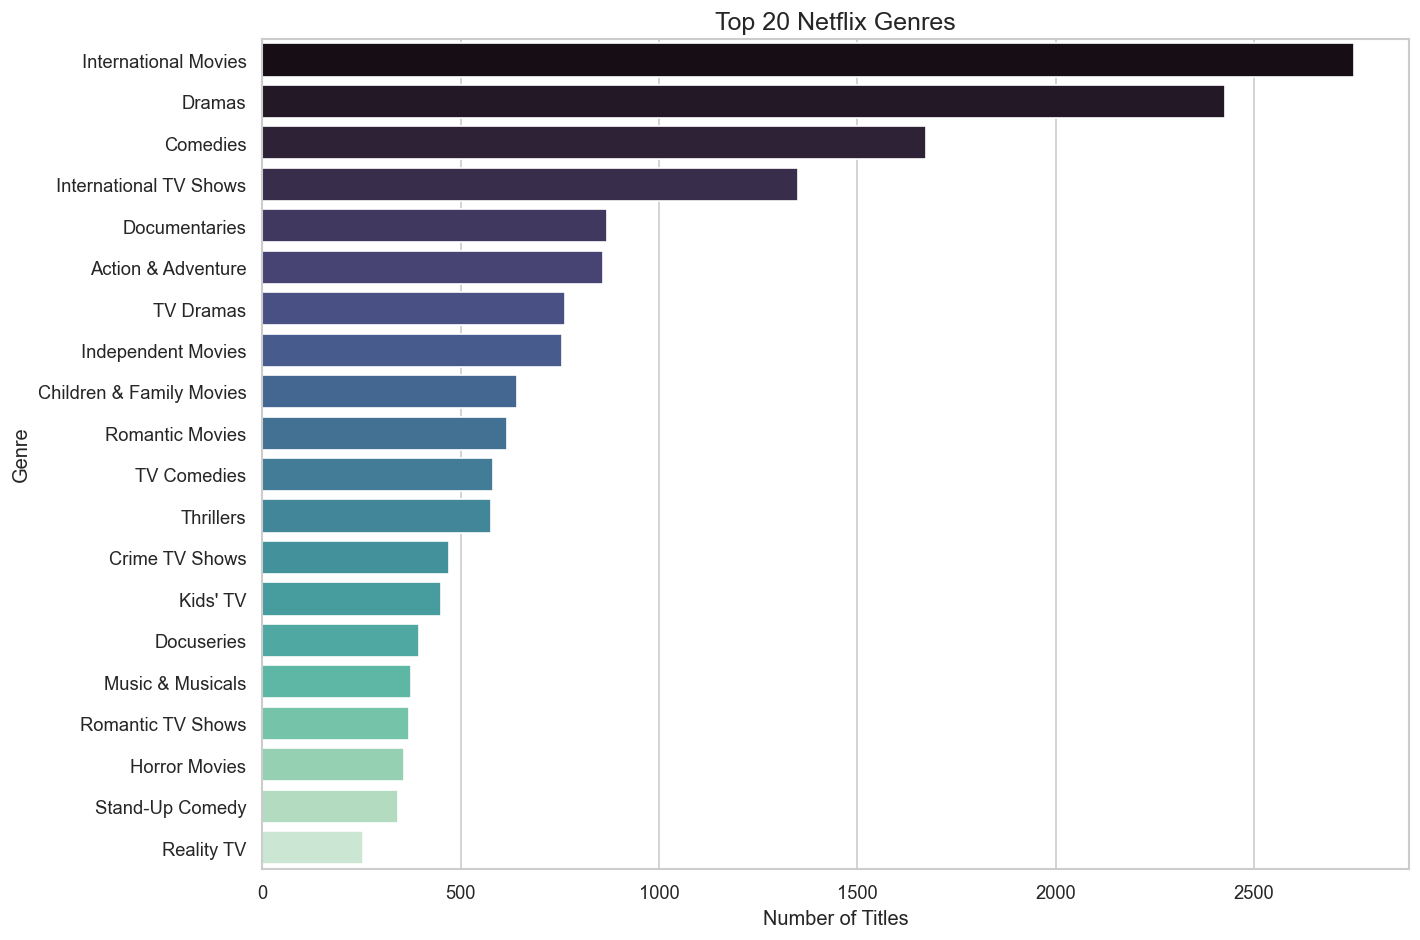

In [36]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="mako")
plt.title("Top 20 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "top_genres.png", bbox_inches="tight")
plt.show()

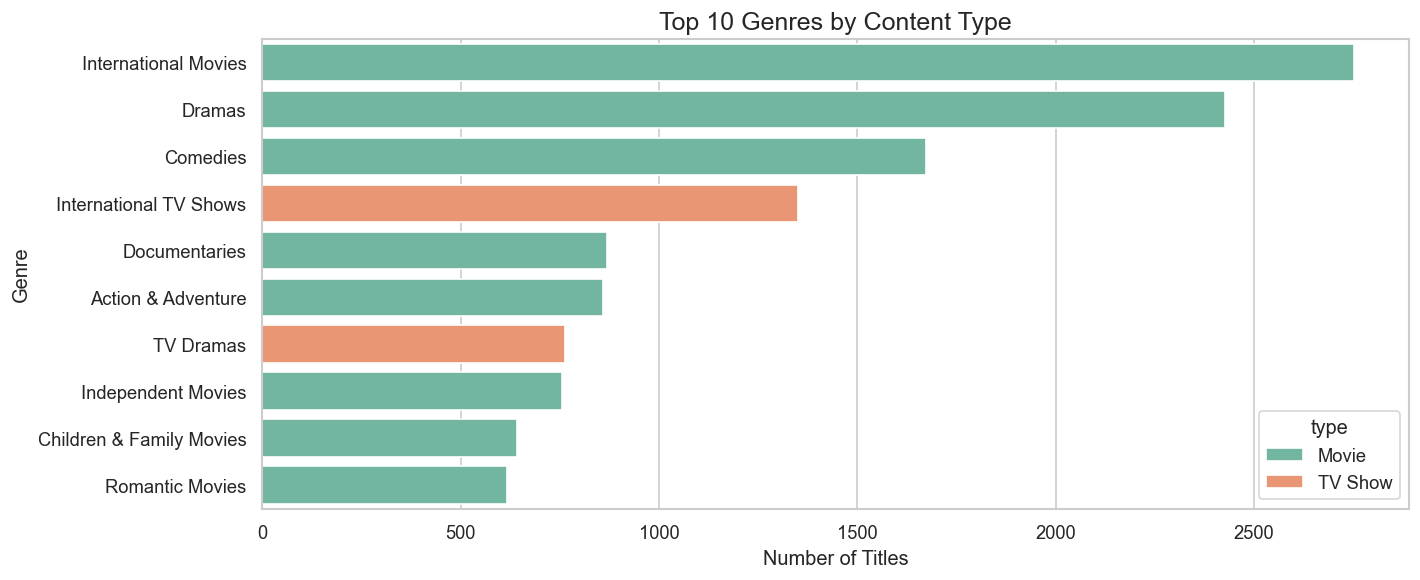

In [43]:
plt.figure(figsize=(12, 5))
sns.countplot(data=genre_exploded.reset_index(drop=True), y="genre", order=top_genres.head(10).index, hue="type", palette="Set2")
plt.title("Top 10 Genres by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

In [44]:
top_genre = top_genres.index[0]
top_genre_count = int(top_genres.iloc[0])

display(Markdown(f'''
**Genre Analysis Insights**

- **{top_genre}** is the most common genre, appearing in **{top_genre_count:,} titles**.
- Genre distribution shows which content categories dominate the Netflix catalog.
- Comparing genre mix by type reveals whether certain genres are more movie-oriented or TV-oriented.

**Business implication:** Genre demand and supply patterns can inform content acquisition, recommendation modules, and campaign targeting.
'''))


**Genre Analysis Insights**

- **International Movies** is the most common genre, appearing in **2,752 titles**.
- Genre distribution shows which content categories dominate the Netflix catalog.
- Comparing genre mix by type reveals whether certain genres are more movie-oriented or TV-oriented.

**Business implication:** Genre demand and supply patterns can inform content acquisition, recommendation modules, and campaign targeting.


### E. Rating Analysis

In [47]:
netflix.loc[netflix["rating"].astype(str).str.contains("min")]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,country_count,cast_count,director_count,has_director,has_cast,has_country,release_era,maturity_segment,added_quarter,added_season
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,2017-04-04,2017,74 min,Unknown Duration,...,1,1,1,True,True,True,2016+,Unrated/Other,2.0,Spring
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,2016-09-16,2010,84 min,Unknown Duration,...,1,1,1,True,True,True,2010-2015,Unrated/Other,3.0,Fall
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,2016-08-15,2015,66 min,Unknown Duration,...,1,1,1,True,True,True,2010-2015,Unrated/Other,3.0,Summer


In [48]:
mask = netflix["rating"].astype(str).str.contains("min", na=False)

netflix.loc[mask, "duration"] = netflix.loc[mask, "rating"]
netflix.loc[mask, "rating"] = "Unknown Rating"

In [49]:
rating_counts = netflix["rating"].value_counts()
movie_ratings = netflix.query("type == 'Movie'")["rating"].value_counts()
tv_ratings = netflix.query("type == 'TV Show'")["rating"].value_counts()

display(rating_counts.to_frame("count"))

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


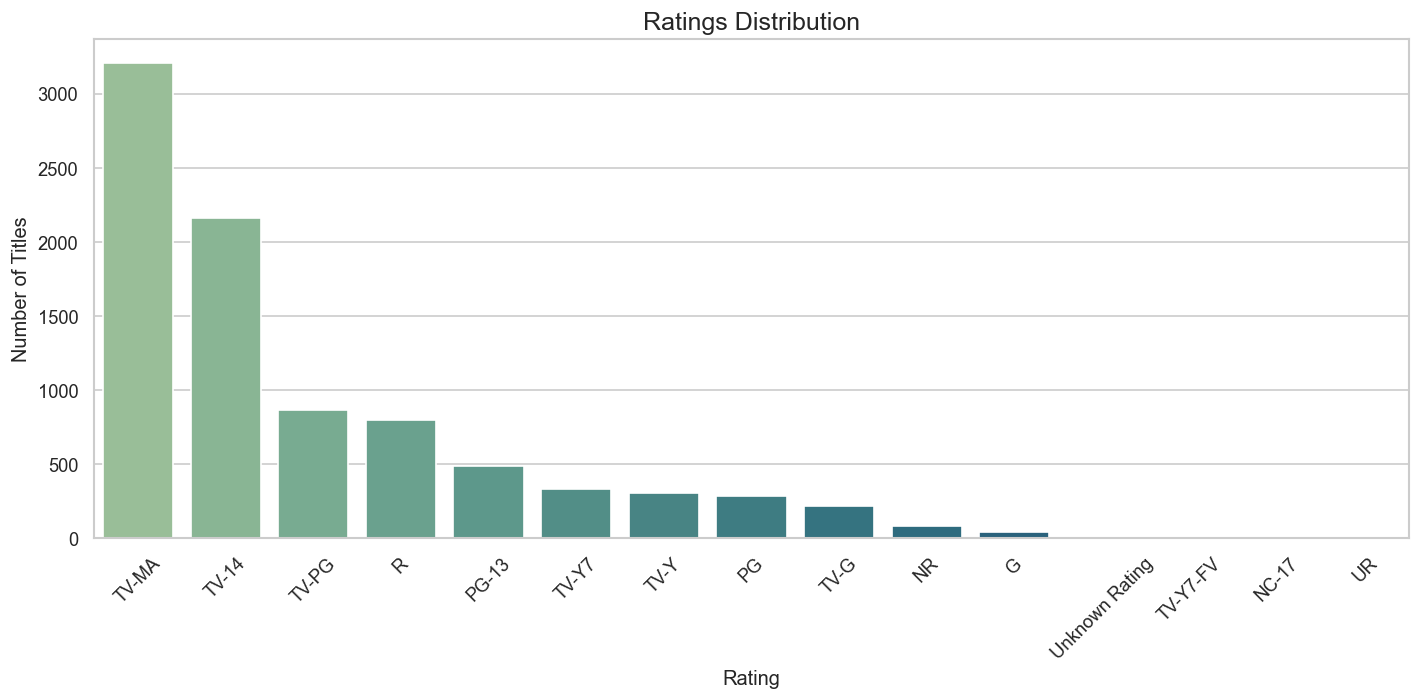

In [50]:
plt.figure(figsize=(12, 6))
sns.countplot(data=netflix, x="rating", order=rating_counts.index, palette="crest")
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "ratings_distribution.png", bbox_inches="tight")
plt.show()

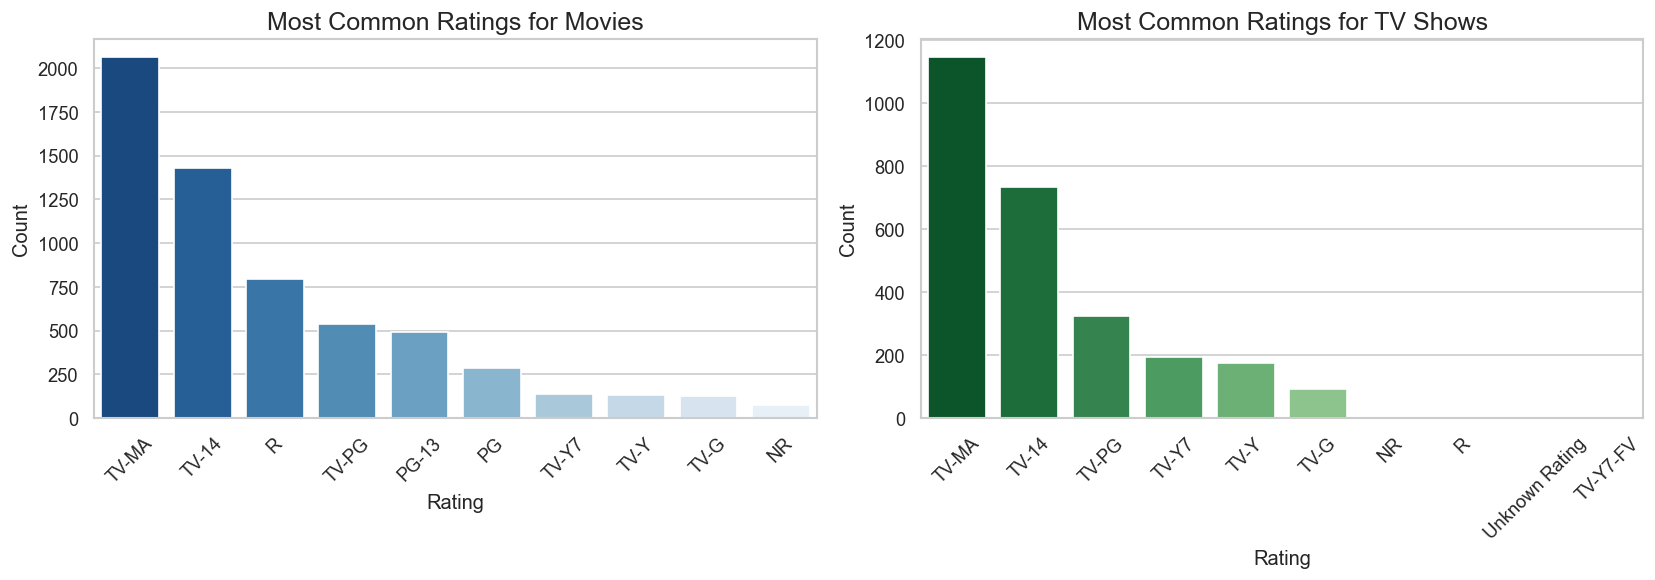

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=movie_ratings.head(10).index, y=movie_ratings.head(10).values, ax=axes[0], palette="Blues_r")
axes[0].set_title("Most Common Ratings for Movies")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=tv_ratings.head(10).index, y=tv_ratings.head(10).values, ax=axes[1], palette="Greens_r")
axes[1].set_title("Most Common Ratings for TV Shows")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [52]:
most_common_rating = rating_counts.index[0]
most_common_rating_count = int(rating_counts.iloc[0])

display(Markdown(f'''
**Rating Analysis Insights**

- **{most_common_rating}** is the most common rating, appearing in **{most_common_rating_count:,} titles**.
- Movie and TV rating profiles can differ, reflecting different audience targets and content maturity levels.
- Ratings distribution helps identify whether the catalog is concentrated around family, teen, or mature audiences.

**Business implication:** Ratings analysis supports parental-control design, personalized recommendations, and audience-specific marketing.
'''))


**Rating Analysis Insights**

- **TV-MA** is the most common rating, appearing in **3,207 titles**.
- Movie and TV rating profiles can differ, reflecting different audience targets and content maturity levels.
- Ratings distribution helps identify whether the catalog is concentrated around family, teen, or mature audiences.

**Business implication:** Ratings analysis supports parental-control design, personalized recommendations, and audience-specific marketing.


### F. Duration Analysis

In [53]:
movies = netflix[(netflix["type"] == "Movie") & (netflix["duration_unit"].str.contains("min", na=False))]
tv_shows = netflix[(netflix["type"] == "TV Show") & (netflix["duration_unit"].str.contains("Season", na=False))]

display(movies["duration_value"].describe().to_frame("movie_duration_minutes"))
display(tv_shows["duration_value"].describe().to_frame("tv_show_seasons"))

,movie_duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


,tv_show_seasons
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


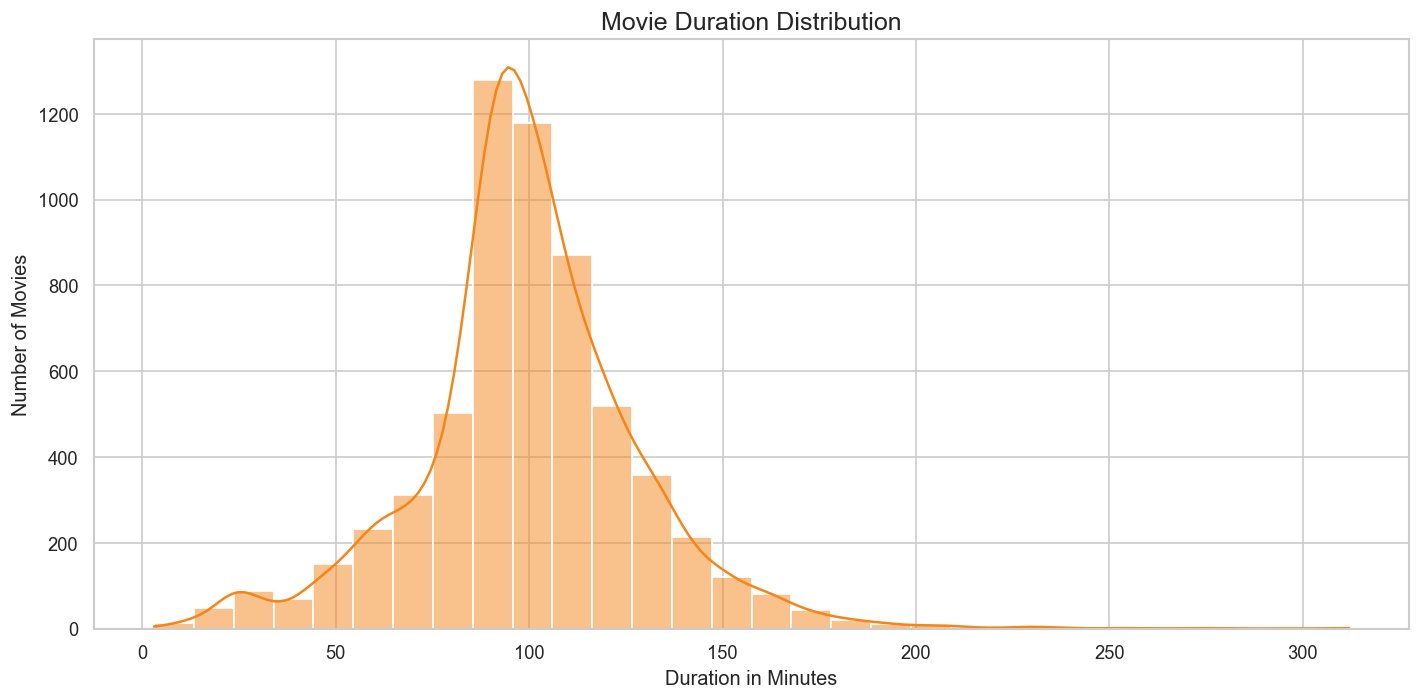

In [93]:
plt.figure(figsize=(12, 6))
sns.histplot(data=movies, x="duration_value", bins=30, kde=True, color="#F58518")
plt.title("Movie Duration Distribution")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "Movie_duration.png", bbox_inches="tight")
plt.show()

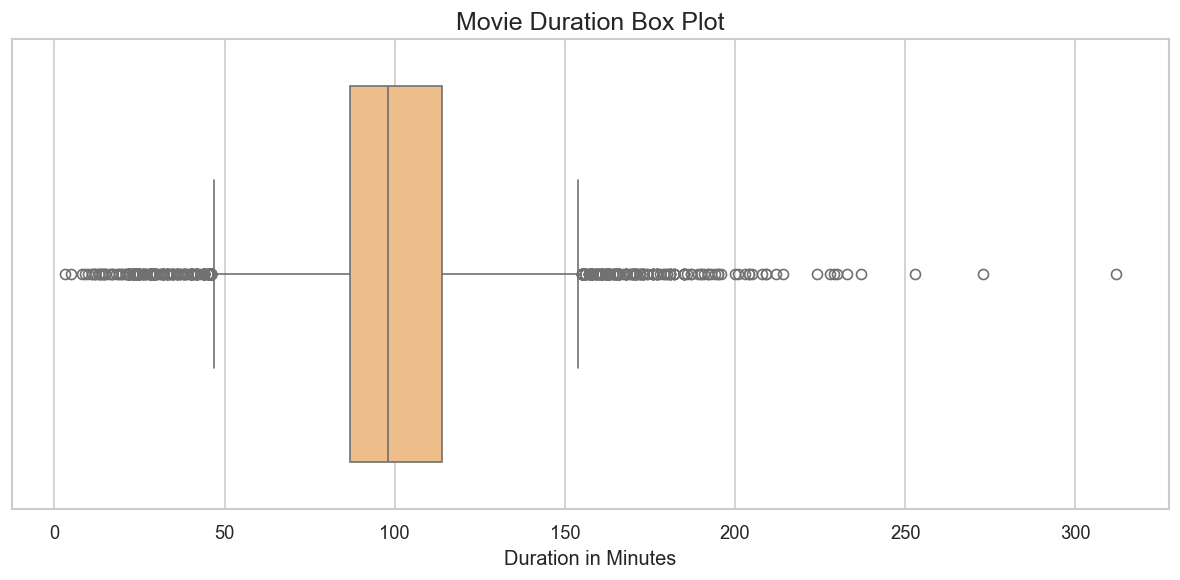

In [55]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=movies, x="duration_value", color="#FFBF79")
plt.title("Movie Duration Box Plot")
plt.xlabel("Duration in Minutes")
plt.tight_layout()
plt.show()

In [56]:
longest_movies = movies.sort_values("duration_value", ascending=False)[["title", "duration_value", "release_year", "rating"]].head(10)
display(longest_movies)

,title,duration_value,release_year,rating
4253,Black Mirror: Bandersnatch,312.0,2018,TV-MA
717,Headspace: Unwind Your Mind,273.0,2021,TV-G
2491,The School of Mischief,253.0,1973,TV-14
2487,No Longer kids,237.0,1979,TV-14
2484,Lock Your Girls In,233.0,1982,TV-PG
2488,Raya and Sakina,230.0,1984,TV-14
166,Once Upon a Time in America,229.0,1984,R
7932,Sangam,228.0,1964,TV-14
1019,Lagaan,224.0,2001,PG
4573,Jodhaa Akbar,214.0,2008,TV-14


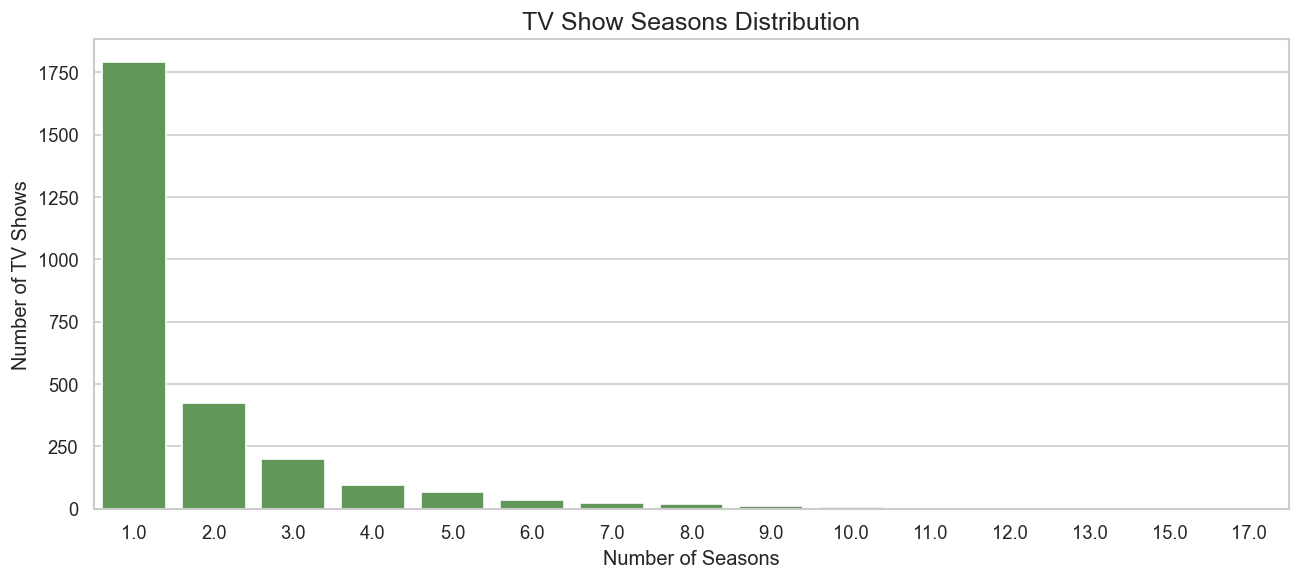

In [94]:
season_distribution = tv_shows["duration_value"].value_counts().sort_index()

plt.figure(figsize=(11, 5))
sns.barplot(x=season_distribution.index, y=season_distribution.values, color="#59A14F")
plt.title("TV Show Seasons Distribution")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "TV_shows_seasons_distribution.png", bbox_inches="tight")
plt.show()

In [58]:
avg_movie_duration = movies["duration_value"].mean()
most_common_seasons = int(season_distribution.idxmax()) if not season_distribution.empty else 0

display(Markdown(f'''
**Duration Analysis Insights**

- The average movie duration is approximately **{avg_movie_duration:.1f} minutes**.
- The most common TV Show length is **{most_common_seasons} season(s)**.
- The longest movies can be reviewed separately because extremely long runtimes may represent special formats, documentaries, or incorrectly classified content.

**Business implication:** Runtime and season count influence viewing commitment, binge potential, and recommendation strategy.
'''))


**Duration Analysis Insights**

- The average movie duration is approximately **99.6 minutes**.
- The most common TV Show length is **1 season(s)**.
- The longest movies can be reviewed separately because extremely long runtimes may represent special formats, documentaries, or incorrectly classified content.

**Business implication:** Runtime and season count influence viewing commitment, binge potential, and recommendation strategy.


### G. Director Analysis

In [59]:
director_exploded = netflix.assign(
    director_clean=netflix["director"].str.split(",")
).explode("director_clean")
director_exploded["director_clean"] = director_exploded["director_clean"].str.strip()
director_exploded = director_exploded[director_exploded["director_clean"].ne("Unknown Director")]

top_directors = director_exploded["director_clean"].value_counts().head(15)
display(top_directors.to_frame("content_count"))

,content_count
director_clean,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Youssef Chahine,12
Martin Scorsese,12


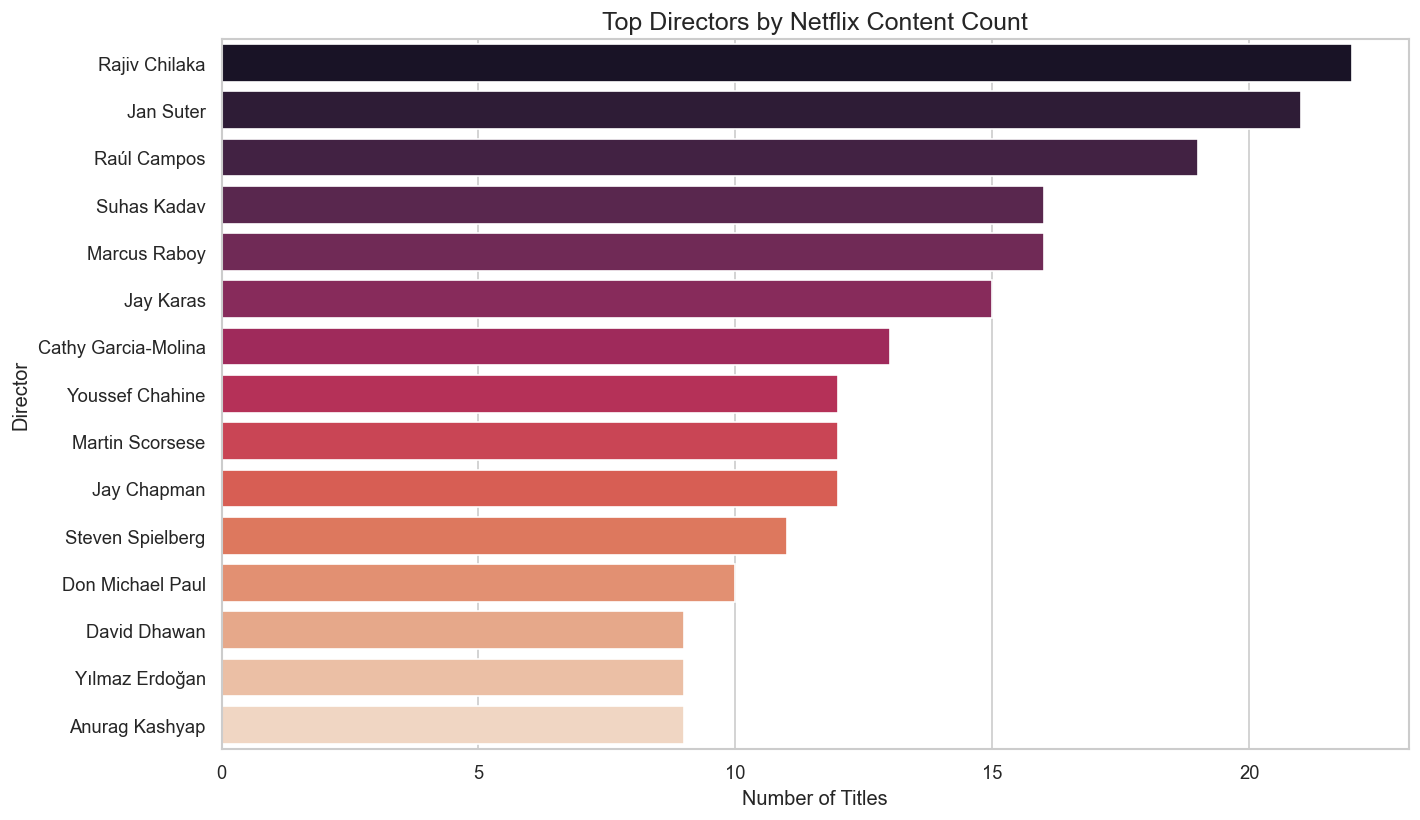

In [60]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_directors.values, y=top_directors.index, palette="rocket")
plt.title("Top Directors by Netflix Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

In [61]:
if not top_directors.empty:
    top_director = top_directors.index[0]
    top_director_count = int(top_directors.iloc[0])
    director_text = f"**{top_director}** has the highest director count with **{top_director_count:,} titles**."
else:
    director_text = "Director metadata is not sufficient to identify top directors."

display(Markdown(f'''
**Director Analysis Insights**

- {director_text}
- Director frequency can reveal repeated partnerships or heavily licensed filmographies.

**Business implication:** Strong director patterns can support talent partnerships, creator-focused collections, and promotional campaigns.
'''))


**Director Analysis Insights**

- **Rajiv Chilaka** has the highest director count with **22 titles**.
- Director frequency can reveal repeated partnerships or heavily licensed filmographies.

**Business implication:** Strong director patterns can support talent partnerships, creator-focused collections, and promotional campaigns.


### H. Cast Analysis

In [62]:
cast_exploded = netflix.assign(
    cast_clean=netflix["cast"].str.split(",")
).explode("cast_clean")
cast_exploded["cast_clean"] = cast_exploded["cast_clean"].str.strip()
cast_exploded = cast_exploded[cast_exploded["cast_clean"].ne("Unknown Cast")]

top_actors = cast_exploded["cast_clean"].value_counts().head(20)
display(top_actors.to_frame("appearance_count"))

,appearance_count
cast_clean,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Naseeruddin Shah,32
Takahiro Sakurai,32
Rupa Bhimani,31
Akshay Kumar,30
Om Puri,30
Yuki Kaji,29


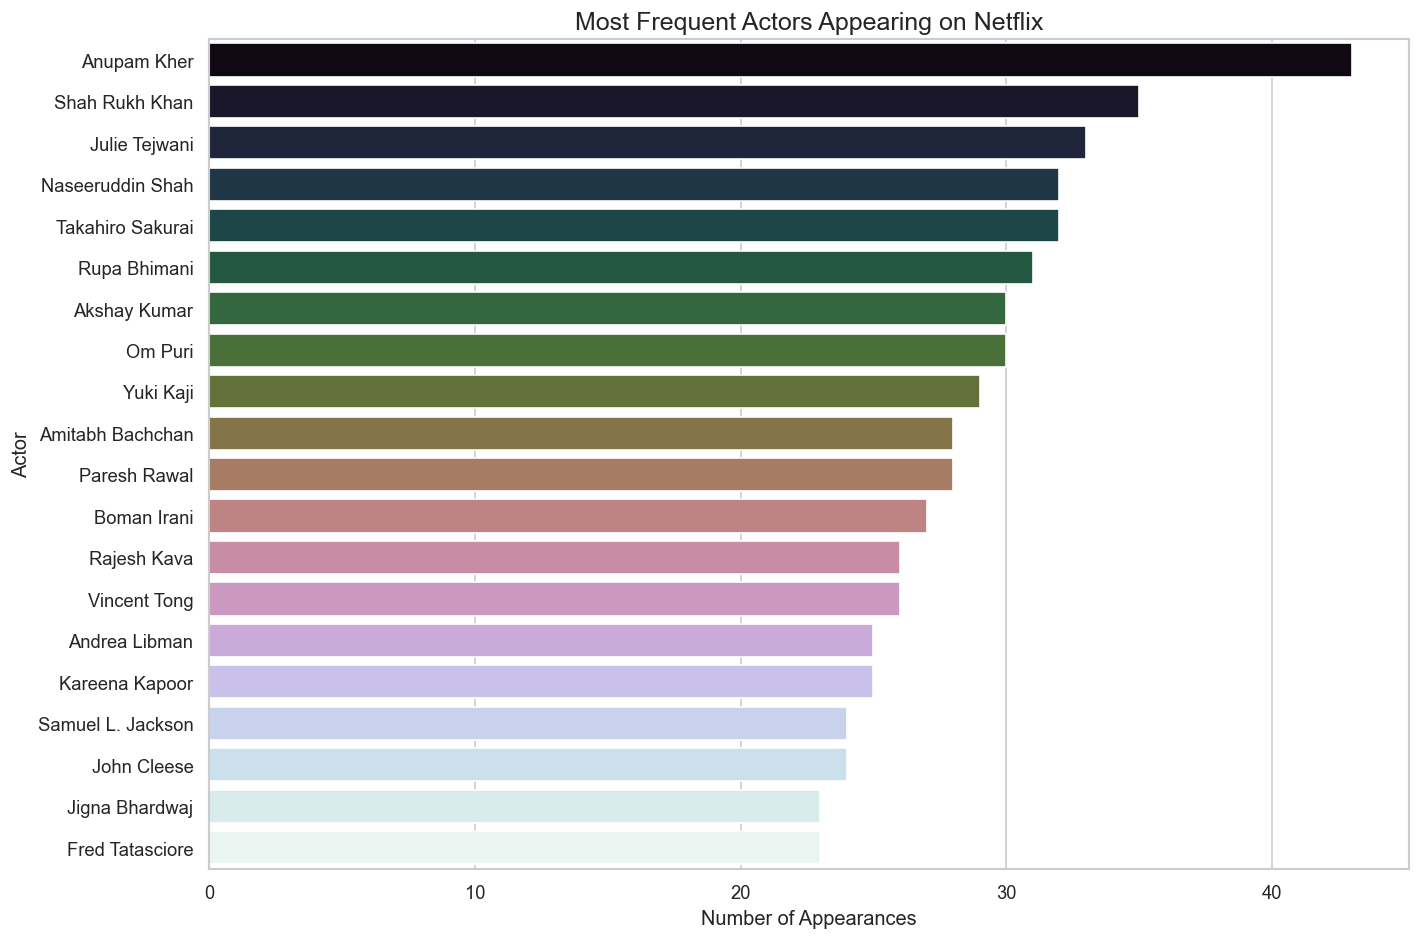

In [63]:
plt.figure(figsize=(12, 8))
sns.barplot(x=top_actors.values, y=top_actors.index, palette="cubehelix")
plt.title("Most Frequent Actors Appearing on Netflix")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

In [64]:
if not top_actors.empty:
    top_actor = top_actors.index[0]
    top_actor_count = int(top_actors.iloc[0])
    actor_text = f"**{top_actor}** appears most frequently, with **{top_actor_count:,} titles**."
else:
    actor_text = "Cast metadata is not sufficient to identify top actors."

display(Markdown(f'''
**Cast Analysis Insights**

- {actor_text}
- High-frequency cast members may reflect strong regional catalogs, long-running franchises, or popular licensing groups.

**Business implication:** Actor-level analysis can support star-led recommendation rows, regional campaigns, and audience acquisition.
'''))


**Cast Analysis Insights**

- **Anupam Kher** appears most frequently, with **43 titles**.
- High-frequency cast members may reflect strong regional catalogs, long-running franchises, or popular licensing groups.

**Business implication:** Actor-level analysis can support star-led recommendation rows, regional campaigns, and audience acquisition.


### I. Content Type Trends

In [65]:
type_year = (
    netflix.dropna(subset=["year_added"])
    .groupby(["year_added", "type"])
    .size()
    .reset_index(name="count")
)

type_year_pivot = type_year.pivot(index="year_added", columns="type", values="count").fillna(0)
display(type_year_pivot.tail(10))

type,Movie,TV Show
year_added,,
2012.0,3.0,0.0
2013.0,6.0,4.0
2014.0,19.0,4.0
2015.0,56.0,17.0
2016.0,253.0,165.0
2017.0,839.0,325.0
2018.0,1237.0,388.0
2019.0,1424.0,575.0
2020.0,1284.0,594.0


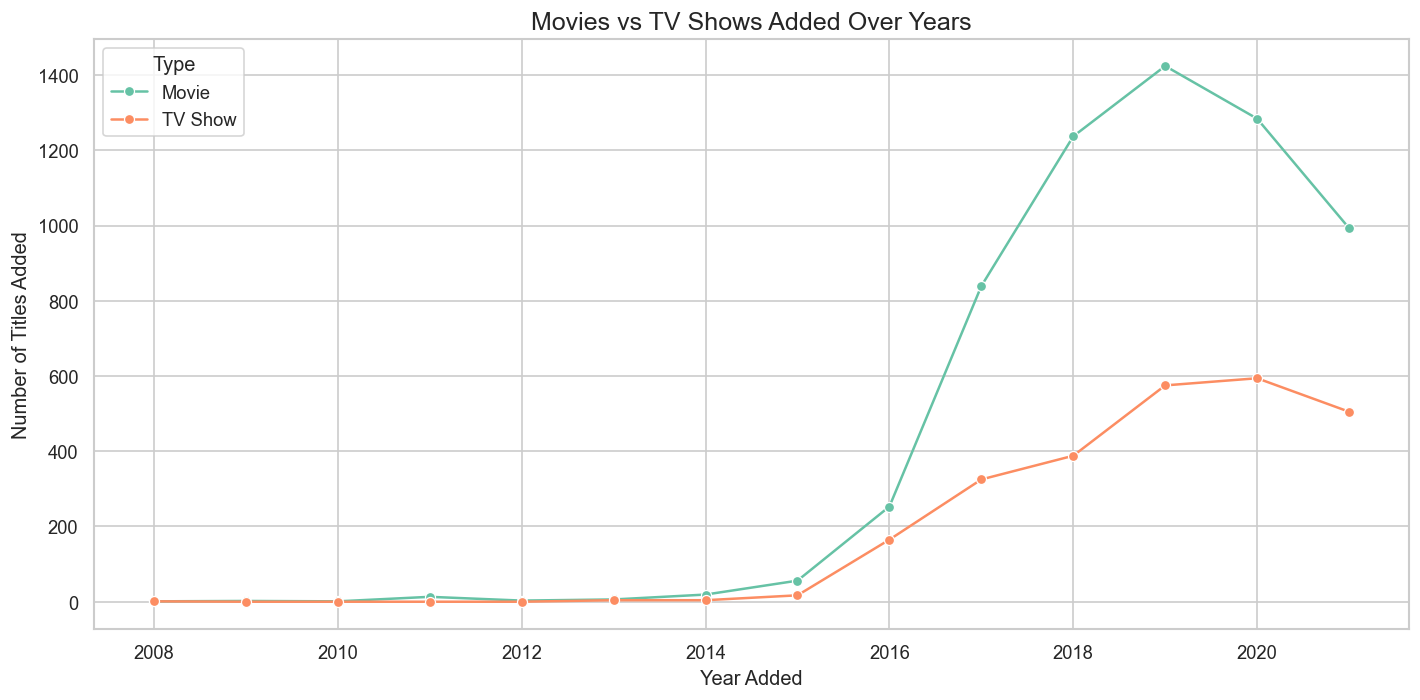

In [66]:
plt.figure(figsize=(12, 6))
for content_type in type_year_pivot.columns:
    sns.lineplot(x=type_year_pivot.index, y=type_year_pivot[content_type], marker="o", label=content_type)

plt.title("Movies vs TV Shows Added Over Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

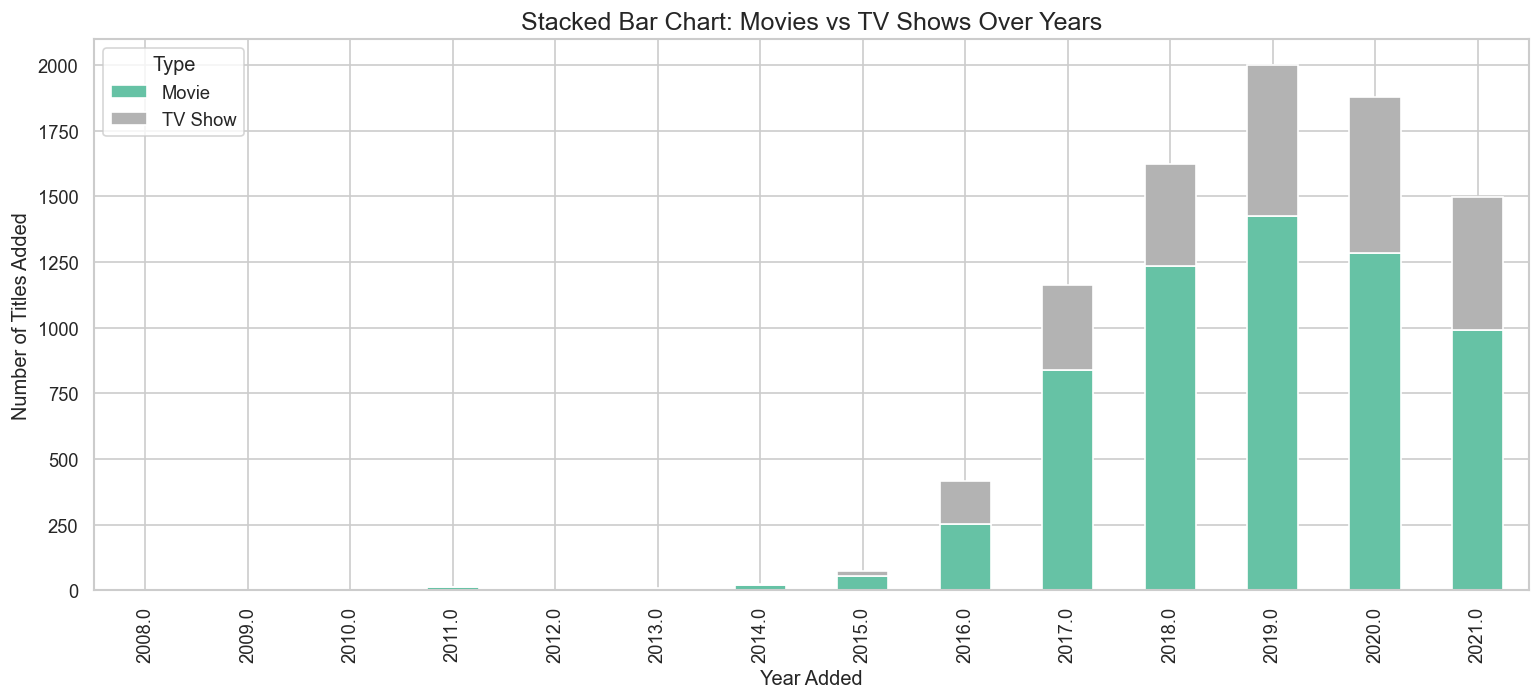

In [67]:
type_year_pivot.plot(kind="bar", stacked=True, figsize=(13, 6), colormap="Set2")
plt.title("Stacked Bar Chart: Movies vs TV Shows Over Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.legend(title="Type")
plt.tight_layout()
plt.show()

In [68]:
latest_year = int(type_year_pivot.index.max())
latest_mix = type_year_pivot.loc[latest_year].sort_values(ascending=False)
latest_top_type = latest_mix.index[0]

display(Markdown(f'''
**Content Type Trend Insights**

- In the latest available addition year (**{latest_year}**), **{latest_top_type}** had the highest count among content types.
- Trend lines show whether Netflix's catalog expansion was more movie-led or TV-led in different periods.
- Stacked bars make yearly portfolio mix shifts easier to compare.

**Business implication:** Content type trends help guide investment between broad movie variety and longer-form episodic engagement.
'''))


**Content Type Trend Insights**

- In the latest available addition year (**2021**), **Movie** had the highest count among content types.
- Trend lines show whether Netflix's catalog expansion was more movie-led or TV-led in different periods.
- Stacked bars make yearly portfolio mix shifts easier to compare.

**Business implication:** Content type trends help guide investment between broad movie variety and longer-form episodic engagement.


### J. Correlation and Advanced Analysis

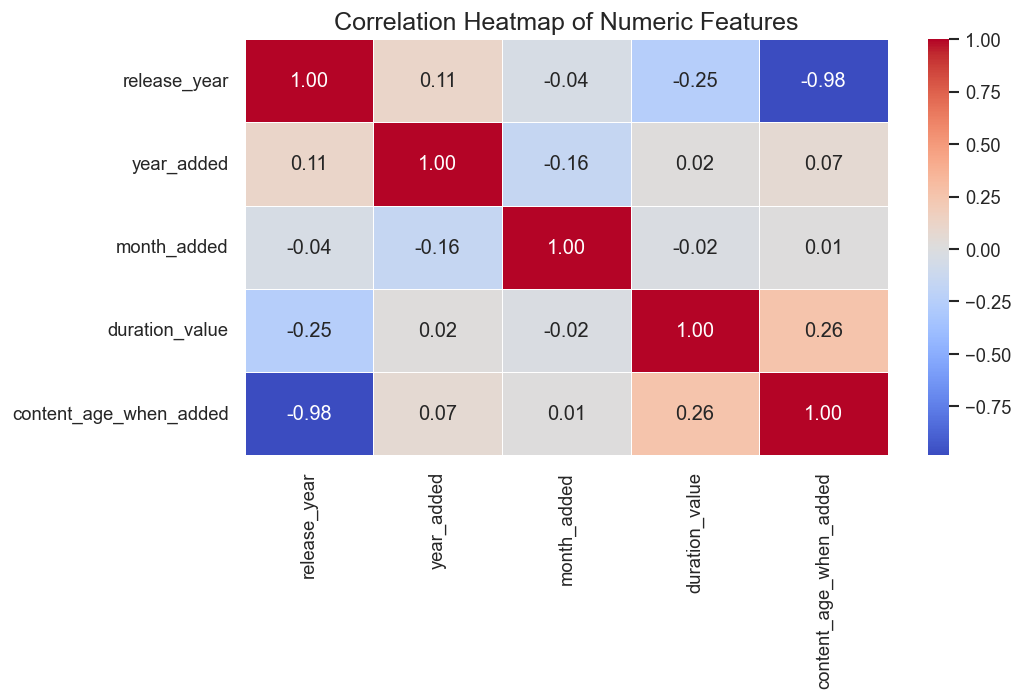

In [69]:
# Numeric correlation heatmap where applicable
numeric_cols = ["release_year", "year_added", "month_added", "duration_value", "content_age_when_added"]
numeric_data = netflix[numeric_cols].copy()
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

type,Movie,TV Show
rating,,
TV-MA,2062,1145
TV-14,1427,733
R,797,2
TV-PG,540,323
PG-13,490,0
PG,287,0
TV-Y7,139,195
TV-Y,131,176
TV-G,126,94


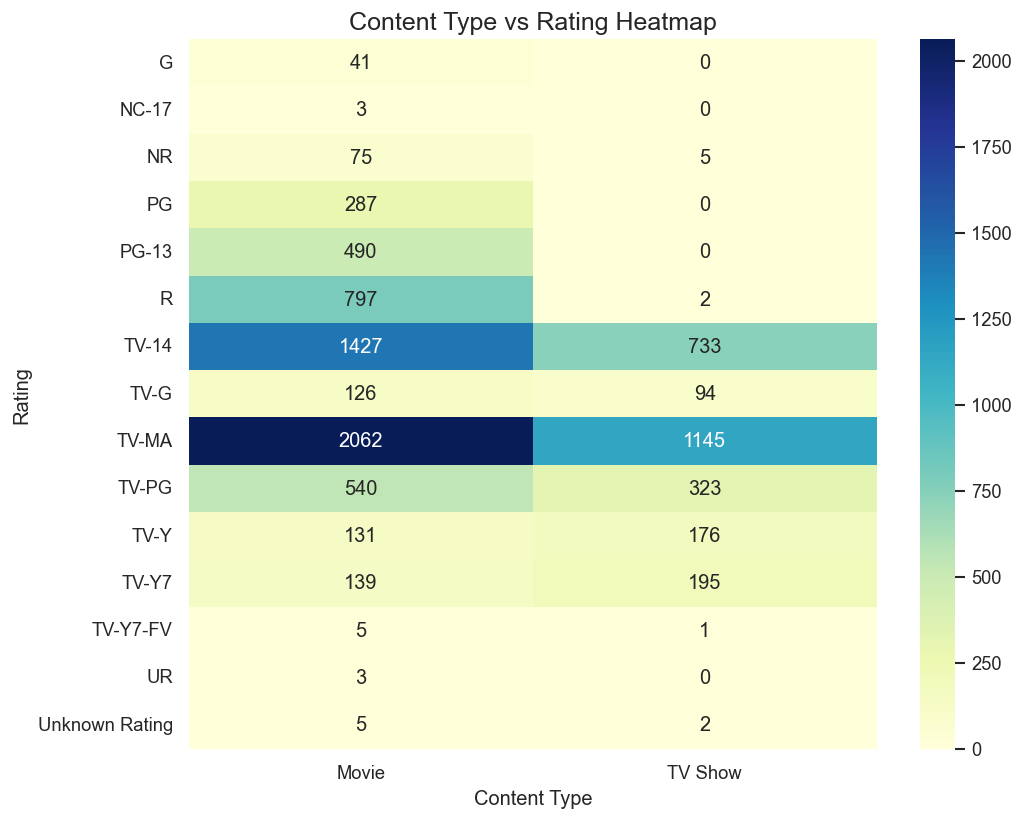

In [70]:
# Cross-tab analysis: content type vs rating
type_rating_crosstab = pd.crosstab(netflix["rating"], netflix["type"])
display(type_rating_crosstab.sort_values(by=type_rating_crosstab.columns.tolist(), ascending=False).head(15))

plt.figure(figsize=(9, 7))
sns.heatmap(type_rating_crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Content Type vs Rating Heatmap")
plt.xlabel("Content Type")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [71]:
# Groupby summaries
groupby_summary = (
    netflix.groupby("type")
    .agg(
        title_count=("show_id", "count"),
        avg_release_year=("release_year", "mean"),
        avg_year_added=("year_added", "mean"),
        avg_duration_value=("duration_value", "mean"),
        median_duration_value=("duration_value", "median"),
    )
    .round(2)
)

display(groupby_summary)

,title_count,avg_release_year,avg_year_added,avg_duration_value,median_duration_value
type,,,,,
Movie,6131,2013.12,2018.85,99.58,98.0
TV Show,2676,2016.61,2018.98,1.76,1.0


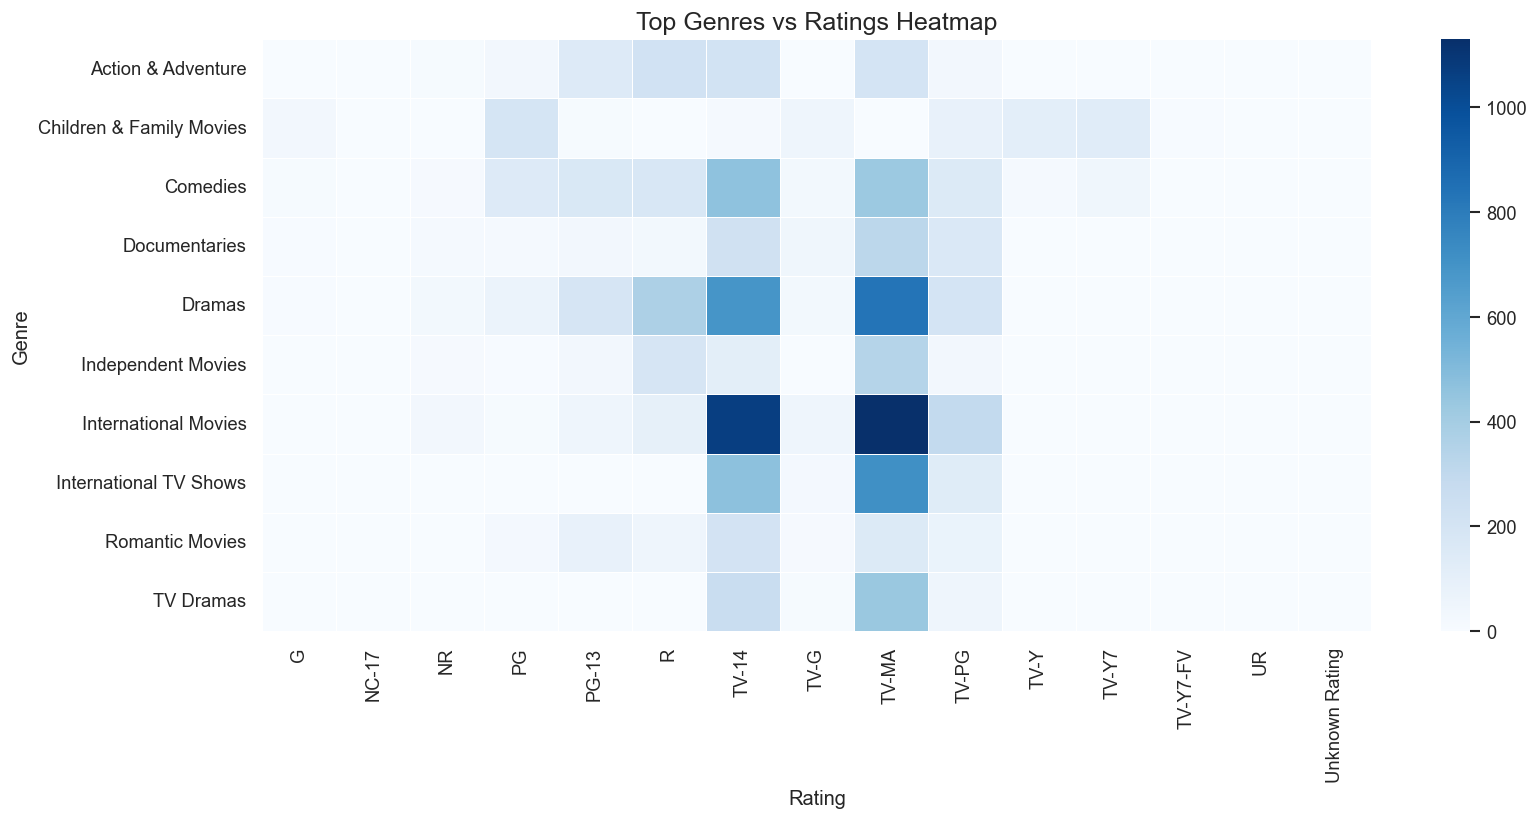

In [72]:
# Genre and rating cross-tab for top genres
top_10_genres = top_genres.head(10).index
genre_rating = pd.crosstab(
    genre_exploded[genre_exploded["genre"].isin(top_10_genres)]["genre"],
    genre_exploded[genre_exploded["genre"].isin(top_10_genres)]["rating"],
)

plt.figure(figsize=(14, 7))
sns.heatmap(genre_rating, cmap="Blues", linewidths=0.3)
plt.title("Top Genres vs Ratings Heatmap")
plt.xlabel("Rating")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

In [73]:
display(Markdown('''
**Advanced Analysis Insights**

- Correlation analysis helps identify relationships between release year, addition year, and duration-related features.
- Rating cross-tabs show how audience suitability differs across Movies and TV Shows.
- Groupby summaries provide a compact comparison of content types across time and duration metrics.

**Business implication:** Advanced summaries help move beyond single-variable charts toward portfolio segmentation and decision-ready analysis.
'''))


**Advanced Analysis Insights**

- Correlation analysis helps identify relationships between release year, addition year, and duration-related features.
- Rating cross-tabs show how audience suitability differs across Movies and TV Shows.
- Groupby summaries provide a compact comparison of content types across time and duration metrics.

**Business implication:** Advanced summaries help move beyond single-variable charts toward portfolio segmentation and decision-ready analysis.


### K. Statistical Observations

In [74]:
# Statistical observations for Movies and TV Shows
movie_duration_stats = movies["duration_value"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)
movie_iqr = movie_duration_stats.loc["75%"] - movie_duration_stats.loc["25%"]
long_movie_threshold = movie_duration_stats.loc["75%"] + 1.5 * movie_iqr
long_movie_outliers = movies[movies["duration_value"] > long_movie_threshold]

tv_season_stats = tv_shows["duration_value"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)
content_age_stats = netflix["content_age_when_added"].dropna().describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)

statistical_summary = pd.DataFrame({
    "metric": [
        "Movie median duration",
        "Movie IQR duration",
        "Long movie outlier threshold",
        "Long movie outlier count",
        "TV Show median seasons",
        "Median content age when added",
        "90th percentile content age when added",
    ],
    "value": [
        f"{movie_duration_stats.loc['50%']:.1f} min",
        f"{movie_iqr:.1f} min",
        f"{long_movie_threshold:.1f} min",
        f"{len(long_movie_outliers):,}",
        f"{tv_season_stats.loc['50%']:.1f} season(s)" if not tv_season_stats.empty else "N/A",
        f"{content_age_stats.loc['50%']:.1f} years",
        f"{content_age_stats.loc['90%']:.1f} years",
    ],
})

display(statistical_summary)

,metric,value
0,Movie median duration,98.0 min
1,Movie IQR duration,27.0 min
2,Long movie outlier threshold,154.5 min
3,Long movie outlier count,201
4,TV Show median seasons,1.0 season(s)
5,Median content age when added,1.0 years
6,90th percentile content age when added,13.0 years


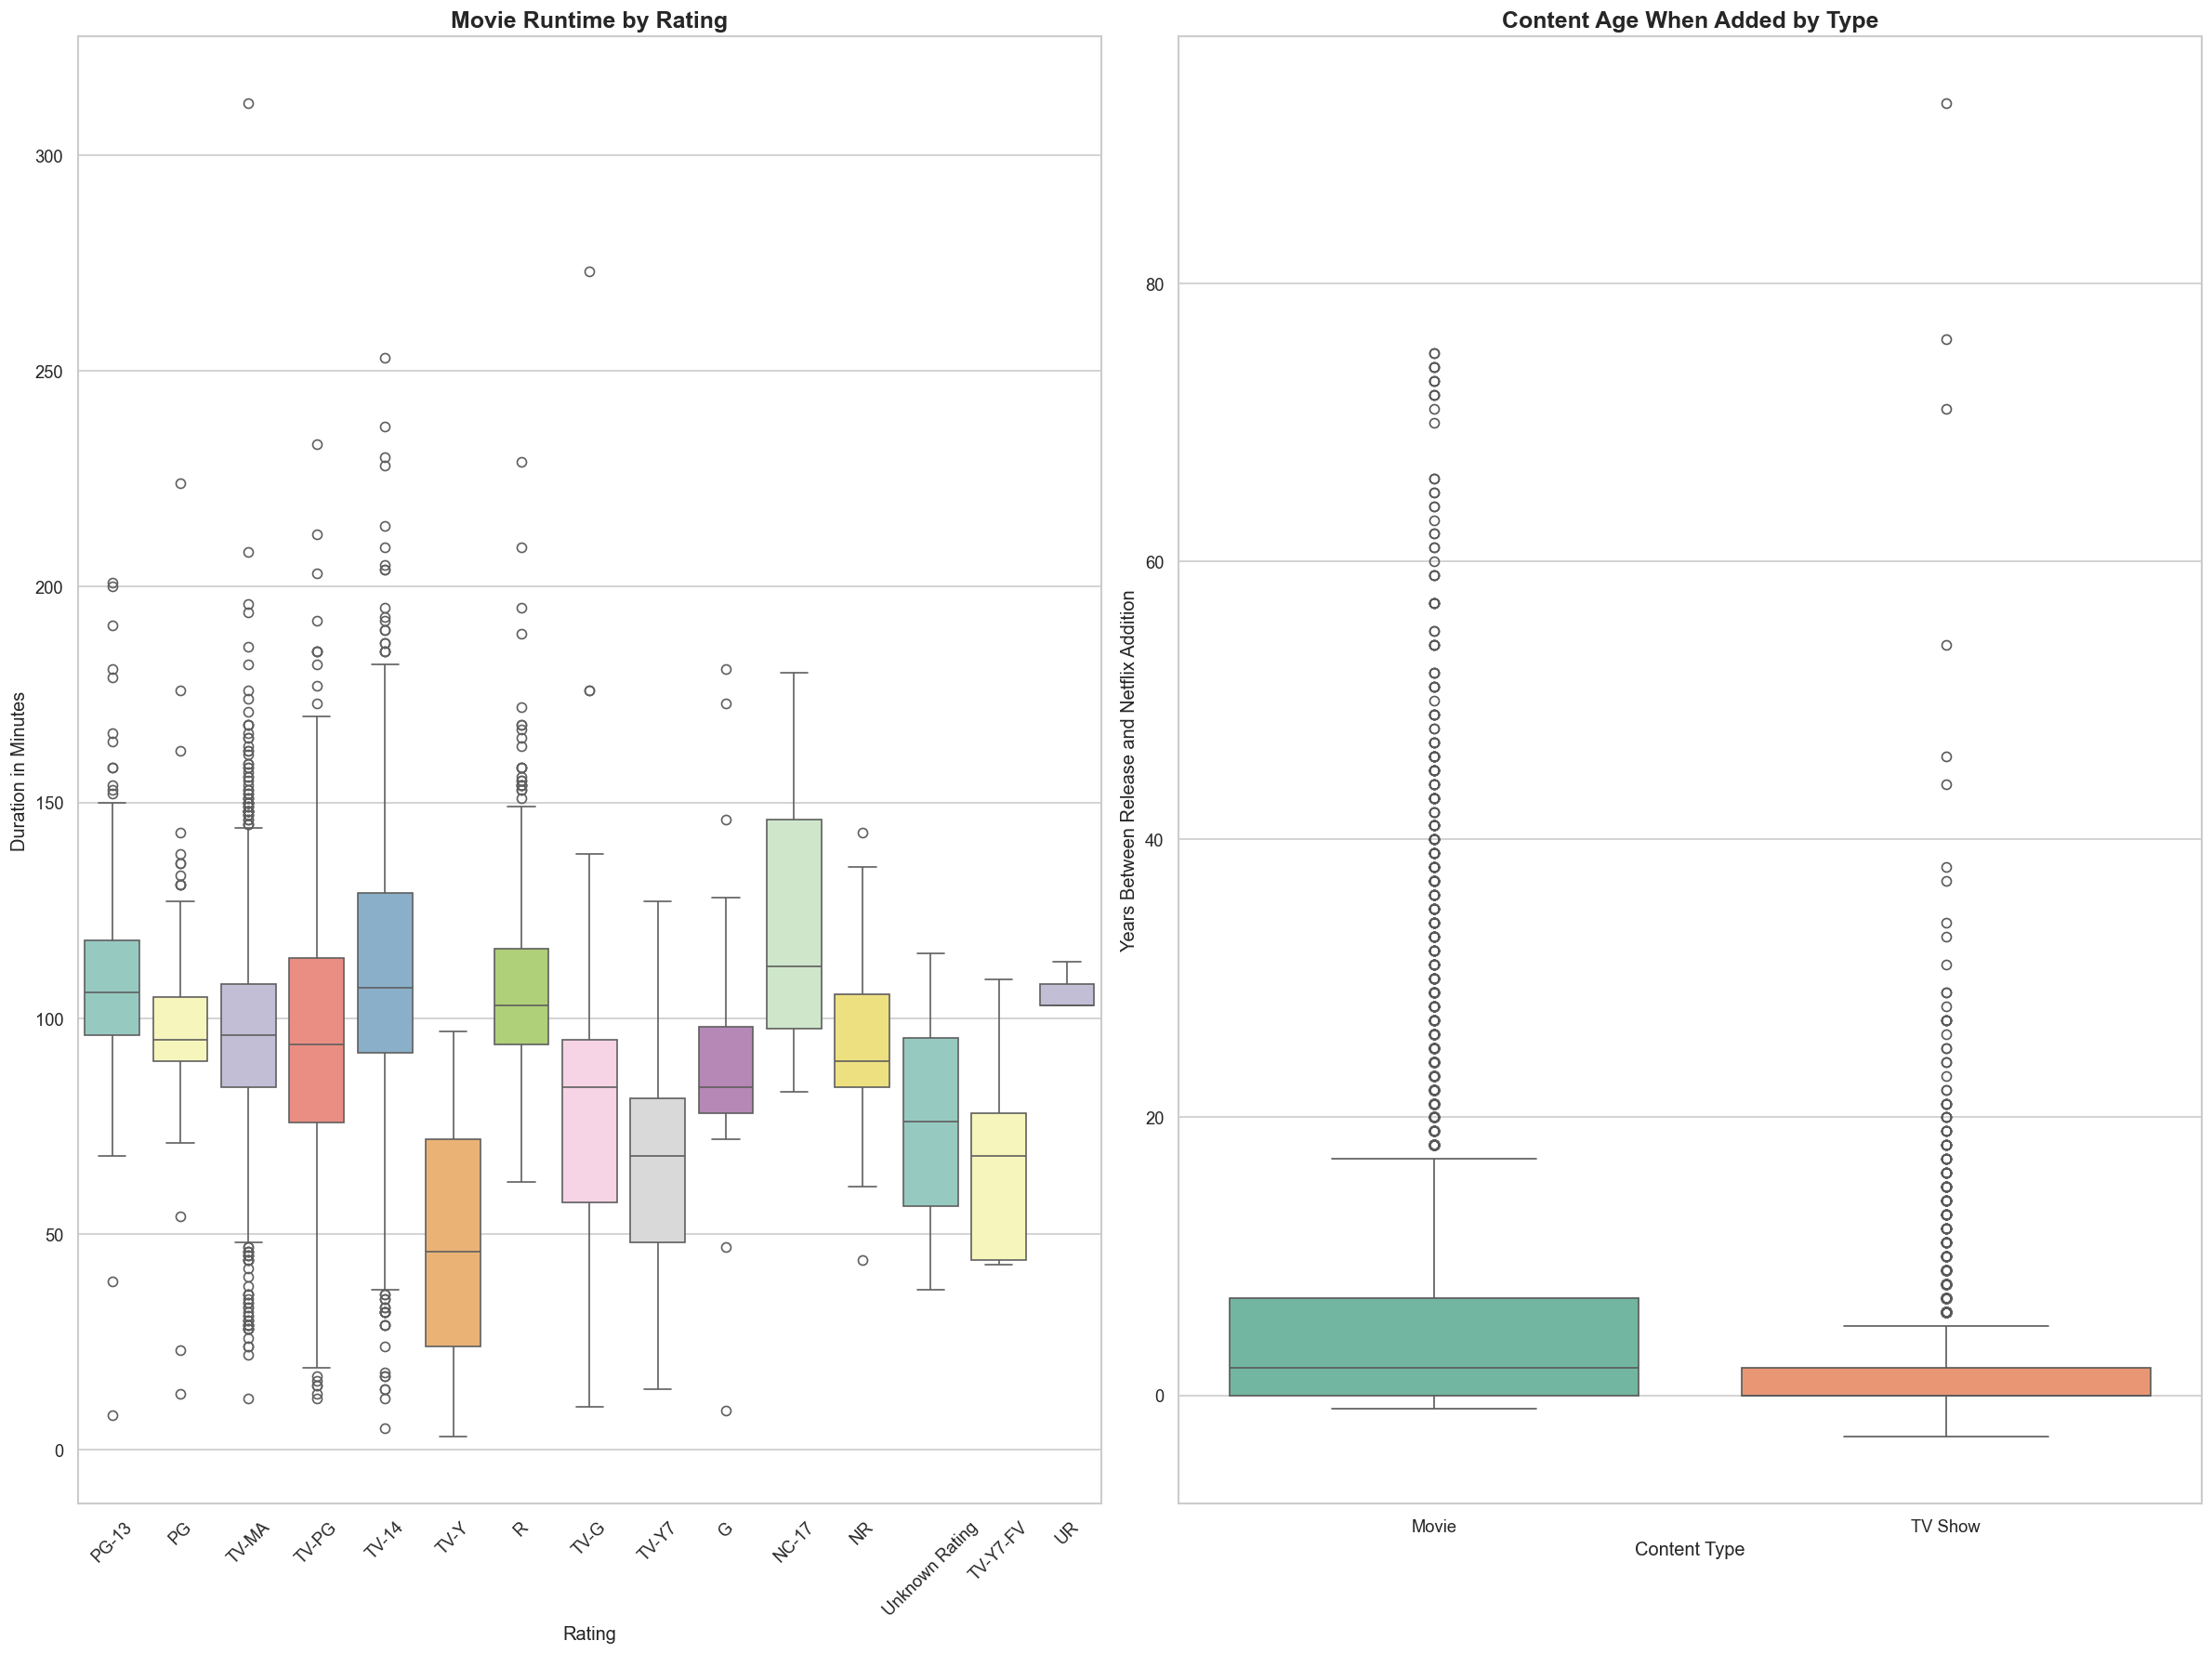

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15))

sns.boxplot(data=movies, x="rating", y="duration_value", ax=axes[0], palette="Set3")
axes[0].set_title("Movie Runtime by Rating", fontweight="bold")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Duration in Minutes")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=netflix.dropna(subset=["content_age_when_added"]), x="type", y="content_age_when_added", ax=axes[1], palette="Set2")
axes[1].set_title("Content Age When Added by Type", fontweight="bold")
axes[1].set_xlabel("Content Type")
axes[1].set_ylabel("Years Between Release and Netflix Addition")

plt.tight_layout()
plt.show()

In [78]:
display(Markdown(f'''
**Statistical Observations**

- The median movie runtime is **{movie_duration_stats.loc['50%']:.1f} minutes**, with an interquartile range of **{movie_iqr:.1f} minutes**.
- Movies above **{long_movie_threshold:.1f} minutes** are statistical high-runtime outliers by the 1.5x IQR rule.
- The median title was added about **{content_age_stats.loc['50%']:.1f} years** after its release.

**Business implication:** Runtime and content-age outliers can be reviewed separately for special programming, niche audiences, licensing value, or metadata quality checks.
'''))


**Statistical Observations**

- The median movie runtime is **98.0 minutes**, with an interquartile range of **27.0 minutes**.
- Movies above **154.5 minutes** are statistical high-runtime outliers by the 1.5x IQR rule.
- The median title was added about **1.0 years** after its release.

**Business implication:** Runtime and content-age outliers can be reviewed separately for special programming, niche audiences, licensing value, or metadata quality checks.


### L. Advanced Trend Analysis

In [79]:
yearly_trends = (
    netflix.dropna(subset=["year_added"])
    .groupby("year_added")
    .agg(
        titles_added=("show_id", "count"),
        movie_share=("type", lambda values: (values == "Movie").mean() * 100),
        tv_share=("type", lambda values: (values == "TV Show").mean() * 100),
        avg_content_age=("content_age_when_added", "mean"),
        mature_share=("maturity_segment", lambda values: (values == "Mature").mean() * 100),
        international_share=("is_international", "mean"),
    )
    .assign(
        yoy_growth_pct=lambda x: x["titles_added"].pct_change() * 100,
        international_share=lambda x: x["international_share"] * 100,
    )
    .round(2)
)

display(yearly_trends.tail(10))

,titles_added,movie_share,tv_share,avg_content_age,mature_share,international_share,yoy_growth_pct
year_added,,,,,,,
2012.0,3,100.00,0.00,1.00,33.33,33.33,-76.92
2013.0,10,60.00,40.00,0.50,30.00,20.00,233.33
2014.0,23,82.61,17.39,2.09,52.17,26.09,130.00
2015.0,73,76.71,23.29,1.29,41.10,16.44,217.39
2016.0,418,60.53,39.47,2.92,41.87,16.75,472.60
2017.0,1164,72.08,27.92,3.92,43.81,15.81,178.47
2018.0,1625,76.12,23.88,4.11,47.45,14.40,39.60
2019.0,1999,71.24,28.76,5.29,46.92,14.06,23.02
2020.0,1878,68.37,31.63,4.67,45.74,15.02,-6.05


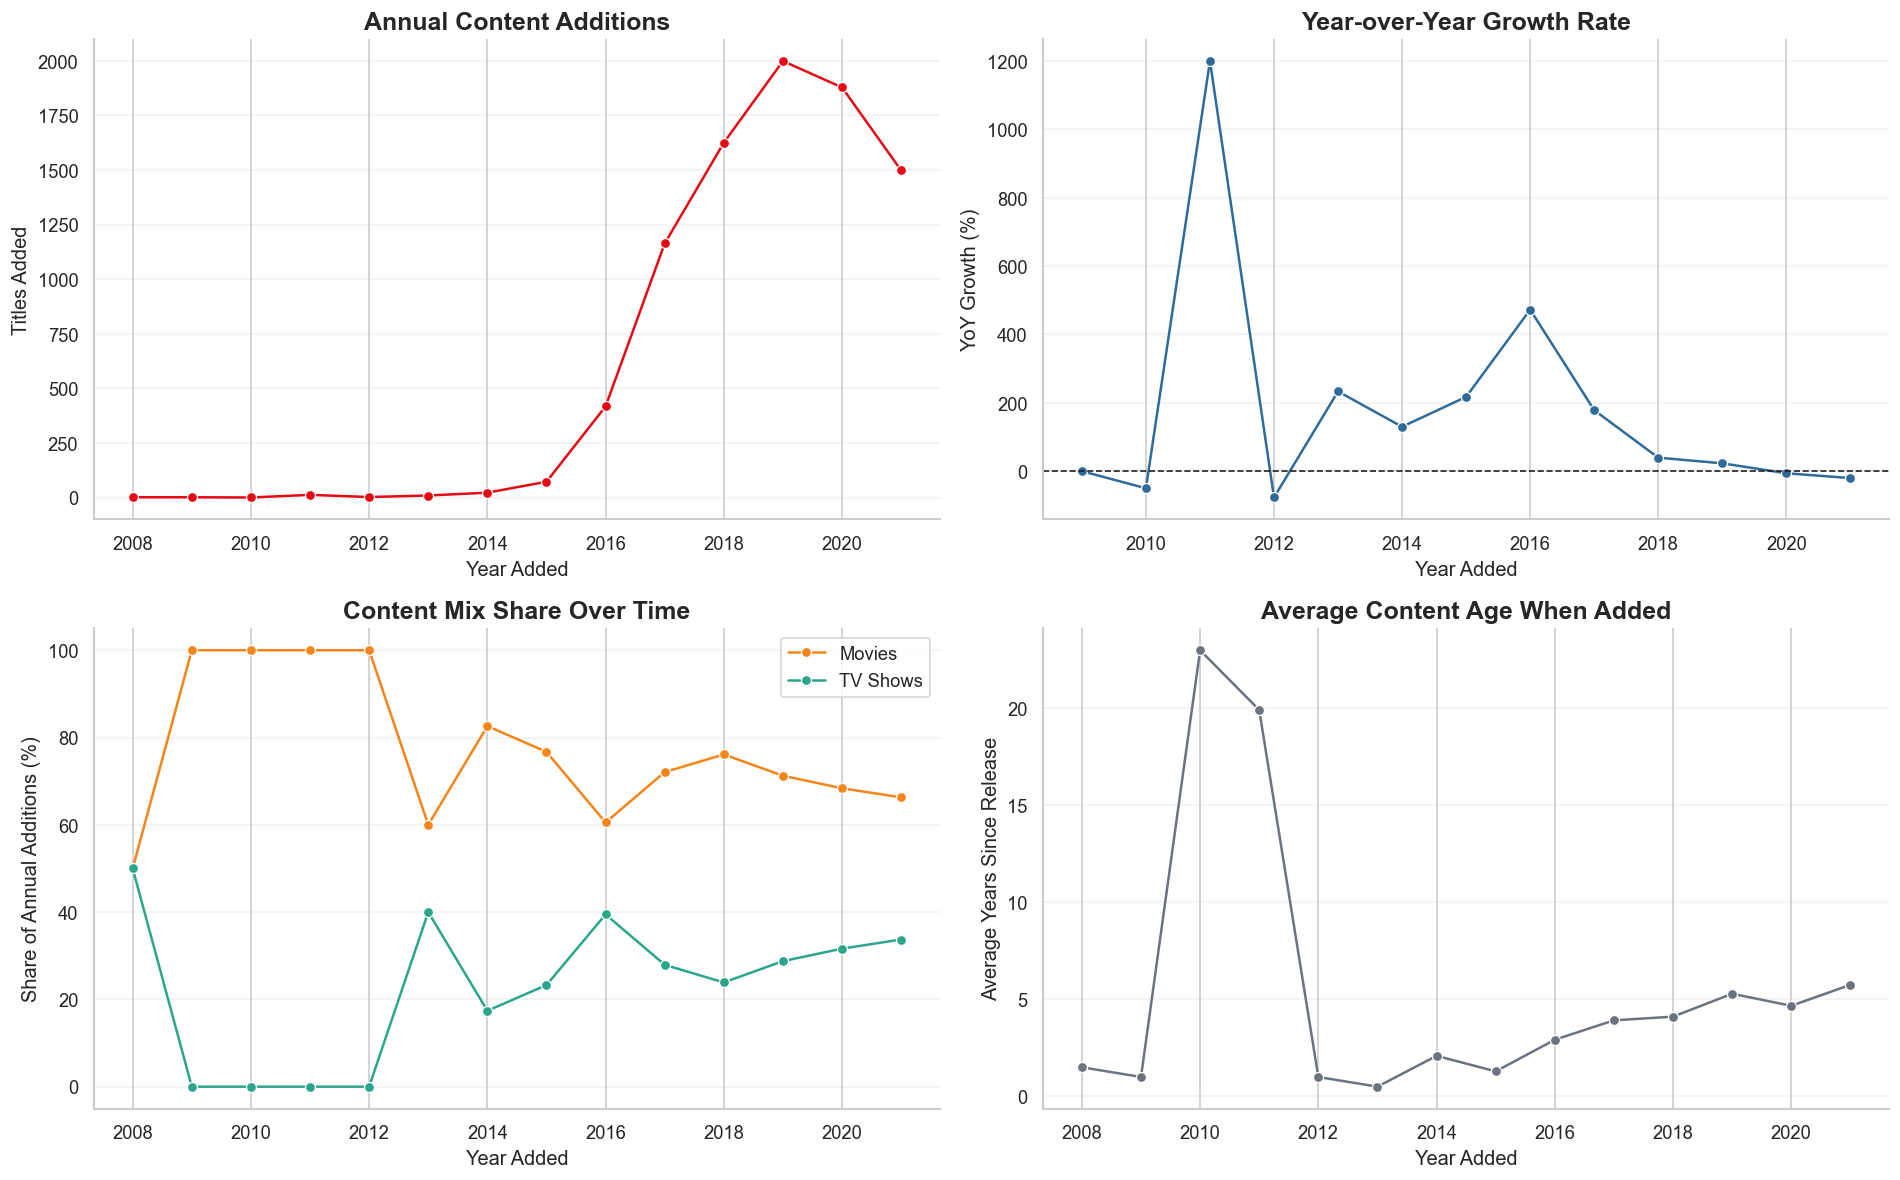

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(data=yearly_trends, x=yearly_trends.index, y="titles_added", marker="o", ax=axes[0, 0], color=BRAND_COLORS["red"])
axes[0, 0].set_title("Annual Content Additions", fontweight="bold")
axes[0, 0].set_xlabel("Year Added")
axes[0, 0].set_ylabel("Titles Added")

sns.lineplot(data=yearly_trends, x=yearly_trends.index, y="yoy_growth_pct", marker="o", ax=axes[0, 1], color=BRAND_COLORS["blue"])
axes[0, 1].axhline(0, color=BRAND_COLORS["black"], linewidth=1, linestyle="--")
axes[0, 1].set_title("Year-over-Year Growth Rate", fontweight="bold")
axes[0, 1].set_xlabel("Year Added")
axes[0, 1].set_ylabel("YoY Growth (%)")

sns.lineplot(data=yearly_trends, x=yearly_trends.index, y="movie_share", marker="o", ax=axes[1, 0], label="Movies", color=BRAND_COLORS["orange"])
sns.lineplot(data=yearly_trends, x=yearly_trends.index, y="tv_share", marker="o", ax=axes[1, 0], label="TV Shows", color=BRAND_COLORS["green"])
axes[1, 0].set_title("Content Mix Share Over Time", fontweight="bold")
axes[1, 0].set_xlabel("Year Added")
axes[1, 0].set_ylabel("Share of Annual Additions (%)")

sns.lineplot(data=yearly_trends, x=yearly_trends.index, y="avg_content_age", marker="o", ax=axes[1, 1], color=BRAND_COLORS["gray"])
axes[1, 1].set_title("Average Content Age When Added", fontweight="bold")
axes[1, 1].set_xlabel("Year Added")
axes[1, 1].set_ylabel("Average Years Since Release")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [81]:
strongest_growth_year = int(yearly_trends["yoy_growth_pct"].idxmax())
strongest_growth_value = yearly_trends.loc[strongest_growth_year, "yoy_growth_pct"]
latest_yoy = yearly_trends["yoy_growth_pct"].dropna().iloc[-1]

display(Markdown(f'''
**Trend Analysis Insights**

- The strongest year-over-year growth occurred in **{strongest_growth_year}**, when annual additions increased by **{strongest_growth_value:.1f}%**.
- The latest available year shows **{latest_yoy:.1f}%** year-over-year change in title additions.
- Tracking content age alongside volume helps distinguish fresh-release acquisition from library expansion.

**Business implication:** Trend analysis helps leadership identify expansion periods, slowdown signals, and whether catalog growth is driven by new releases or older licensed inventory.
'''))


**Trend Analysis Insights**

- The strongest year-over-year growth occurred in **2011**, when annual additions increased by **1200.0%**.
- The latest available year shows **-20.2%** year-over-year change in title additions.
- Tracking content age alongside volume helps distinguish fresh-release acquisition from library expansion.

**Business implication:** Trend analysis helps leadership identify expansion periods, slowdown signals, and whether catalog growth is driven by new releases or older licensed inventory.


### M. Portfolio Segmentation

In [82]:
maturity_type = pd.crosstab(netflix["maturity_segment"], netflix["type"], normalize="columns") * 100
era_type = pd.crosstab(netflix["release_era"], netflix["type"])
quarter_type = pd.crosstab(netflix["added_quarter"], netflix["type"])

display(maturity_type.round(2))
display(era_type)
display(quarter_type)

type,Movie,TV Show
maturity_segment,,
Family/Teen,15.84,19.39
Kids/Family,4.86,10.09
Mature,46.68,42.86
Teen,31.27,27.39
Unrated/Other,1.35,0.26


type,Movie,TV Show
release_era,,
Pre-1980,113,9
1980s,122,7
1990s,241,33
2000s,677,133
2010-2015,1359,457
2016+,3619,2037


type,Movie,TV Show
added_quarter,,
1.0,1457,561
2.0,1481,628
3.0,1603,730
4.0,1590,659


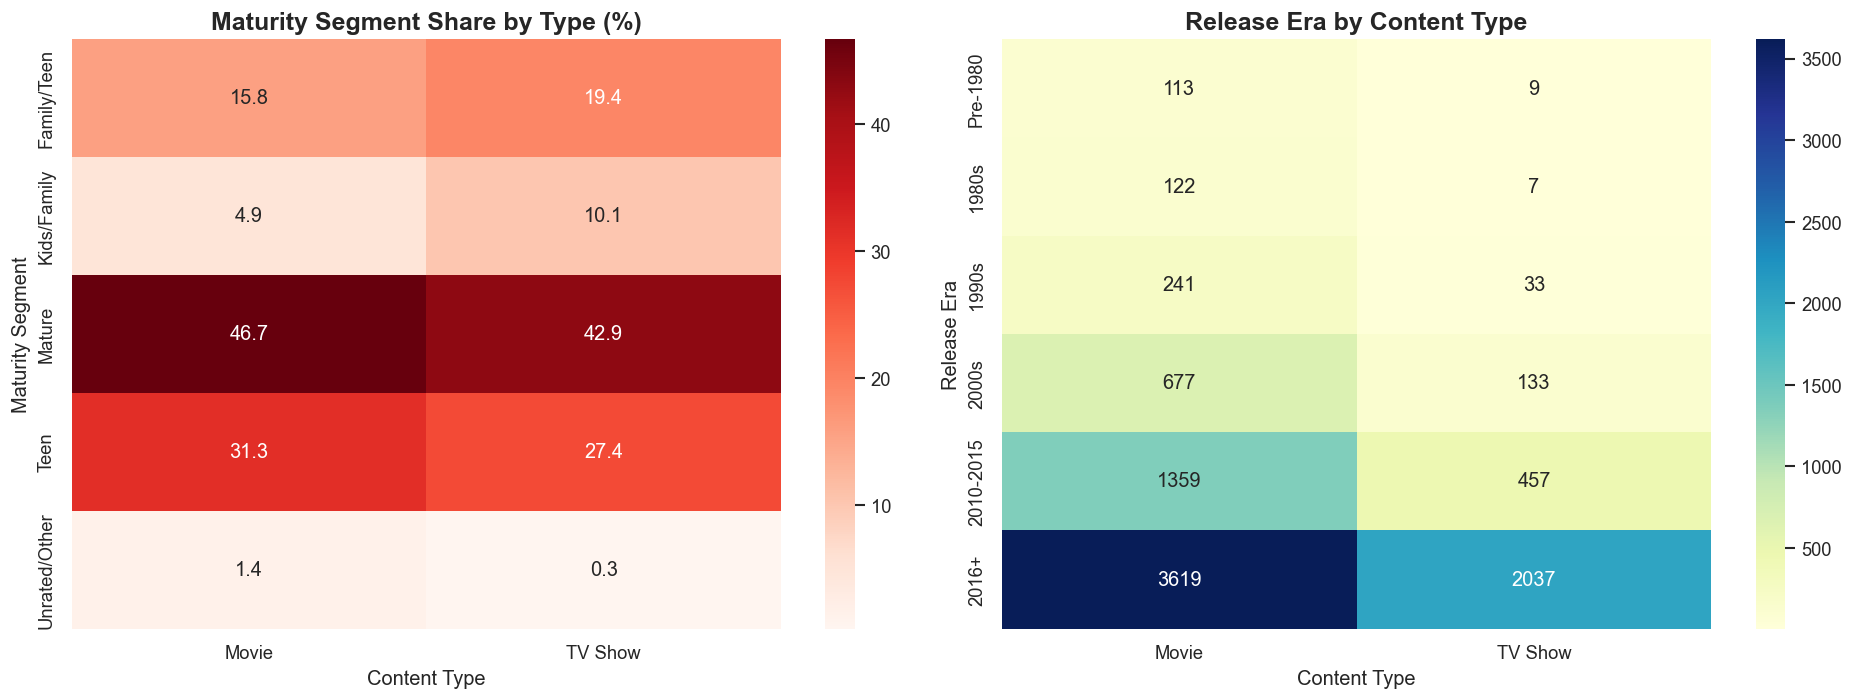

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(maturity_type.round(1), annot=True, fmt=".1f", cmap="Reds", ax=axes[0])
axes[0].set_title("Maturity Segment Share by Type (%)", fontweight="bold")
axes[0].set_xlabel("Content Type")
axes[0].set_ylabel("Maturity Segment")

sns.heatmap(era_type, annot=True, fmt="d", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Release Era by Content Type", fontweight="bold")
axes[1].set_xlabel("Content Type")
axes[1].set_ylabel("Release Era")

plt.tight_layout()
plt.show()

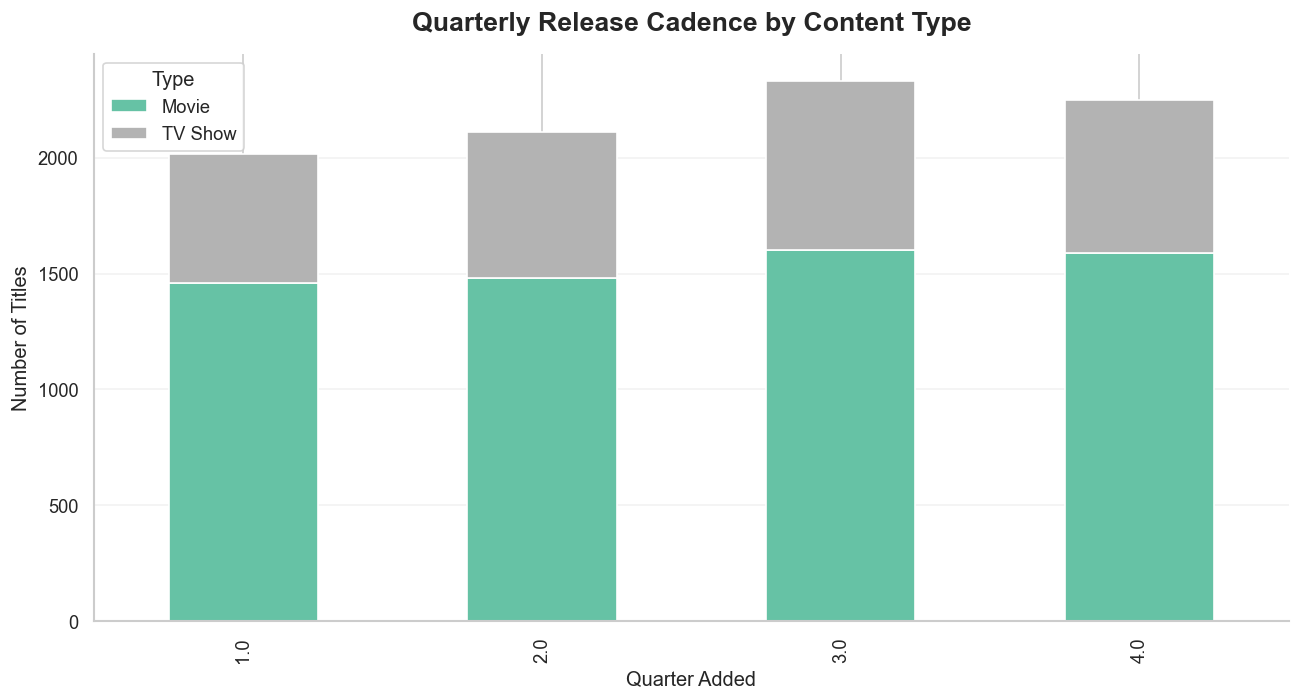

In [84]:
plt.figure(figsize=(11, 6))
quarter_type.plot(kind="bar", stacked=True, colormap="Set2", ax=plt.gca())
polish_chart("Quarterly Release Cadence by Content Type", "Quarter Added", "Number of Titles")
plt.legend(title="Type")
plt.show()

In [85]:
leading_maturity = netflix["maturity_segment"].value_counts().idxmax()
leading_era = netflix["release_era"].value_counts().idxmax()

display(Markdown(f'''
**Portfolio Segmentation Insights**

- **{leading_maturity}** is the largest audience maturity segment in the catalog.
- **{leading_era}** is the most common release-era bucket.
- Quarterly patterns reveal whether content additions are evenly distributed or concentrated in specific planning windows.

**Business implication:** Portfolio segmentation supports more precise content rows, audience targeting, compliance review, and quarterly campaign planning.
'''))


**Portfolio Segmentation Insights**

- **Mature** is the largest audience maturity segment in the catalog.
- **2016+** is the most common release-era bucket.
- Quarterly patterns reveal whether content additions are evenly distributed or concentrated in specific planning windows.

**Business implication:** Portfolio segmentation supports more precise content rows, audience targeting, compliance review, and quarterly campaign planning.


### N. Genre and Country Opportunity Matrix

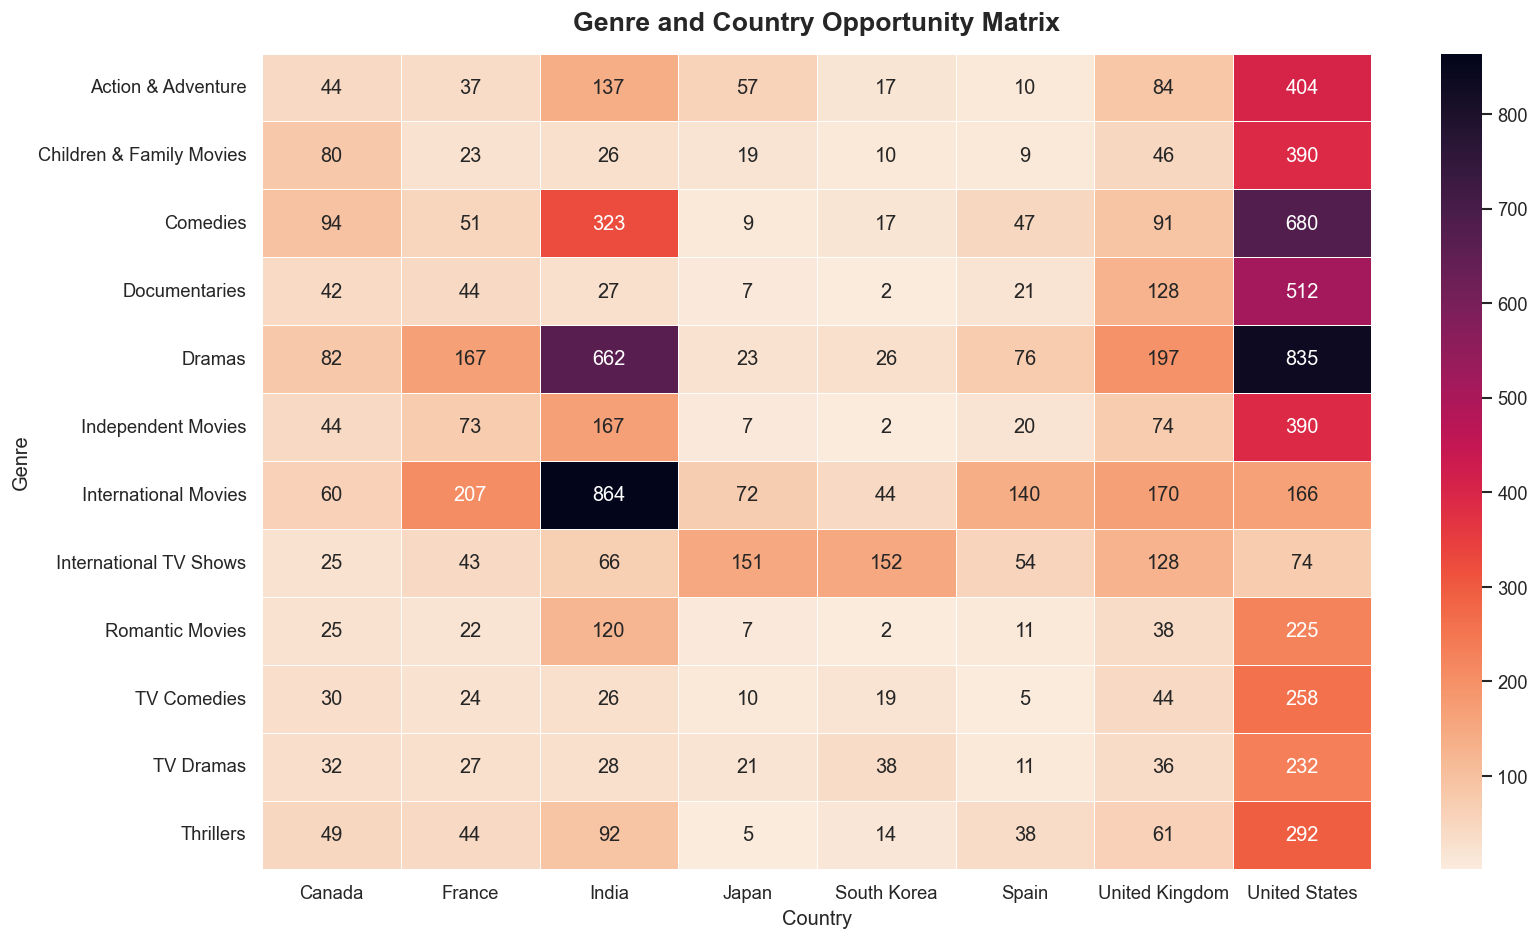

In [86]:
top_12_genres = top_genres.head(12).index
top_8_countries = top_countries.head(8).index

genre_country_matrix = (
    genre_exploded.explode("country_clean")
    .rename(columns={"country_clean": "country_name"})
    .query("genre in @top_12_genres and country_name in @top_8_countries")
    .pivot_table(index="genre", columns="country_name", values="show_id", aggfunc="count", fill_value=0)
)

plt.figure(figsize=(14, 8))
sns.heatmap(genre_country_matrix, annot=True, fmt="d", cmap="rocket_r", linewidths=0.4)
plt.title("Genre and Country Opportunity Matrix", fontsize=16, fontweight="bold", pad=14)
plt.xlabel("Country")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

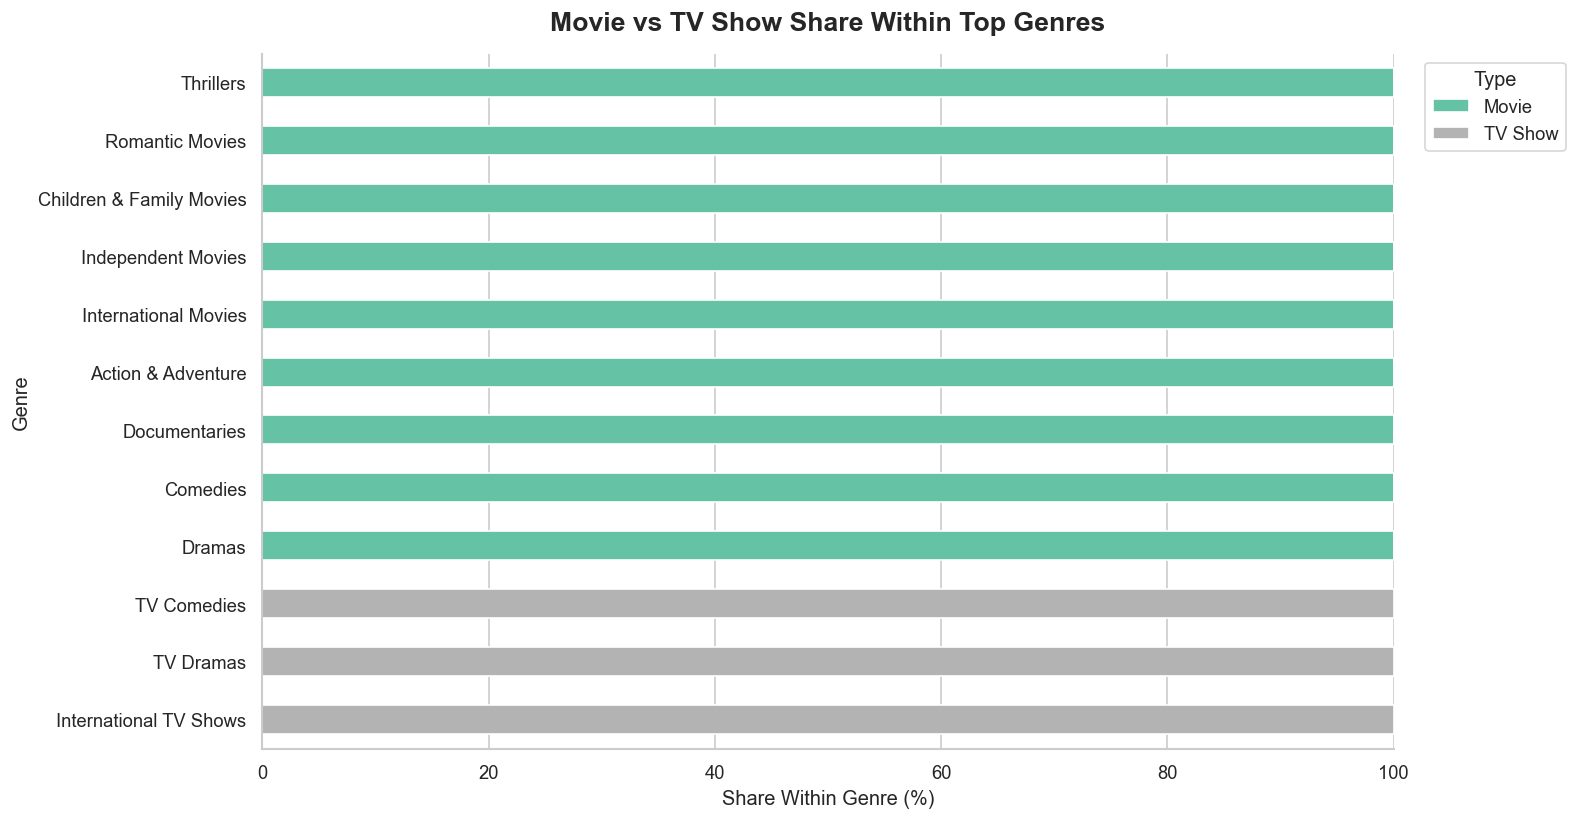

In [87]:
genre_type_share = pd.crosstab(genre_exploded["genre"], genre_exploded["type"], normalize="index") * 100
genre_type_share = genre_type_share.loc[top_12_genres].round(1)

plt.figure(figsize=(12, 7))
genre_type_share.sort_values(by="Movie", ascending=True).plot(kind="barh", stacked=True, colormap="Set2", ax=plt.gca())
polish_chart("Movie vs TV Show Share Within Top Genres", "Share Within Genre (%)", "Genre")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [88]:
display(Markdown('''
**Genre and Country Opportunity Insights**

- The genre-country heatmap highlights where specific content categories are most concentrated.
- Genre type share shows which genres are mainly movie-led versus TV-led.
- Underrepresented genre-country combinations may represent acquisition gaps or deliberate strategic choices.

**Business implication:** This matrix can guide region-specific genre investments, licensing negotiations, and localized merchandising campaigns.
'''))


**Genre and Country Opportunity Insights**

- The genre-country heatmap highlights where specific content categories are most concentrated.
- Genre type share shows which genres are mainly movie-led versus TV-led.
- Underrepresented genre-country combinations may represent acquisition gaps or deliberate strategic choices.

**Business implication:** This matrix can guide region-specific genre investments, licensing negotiations, and localized merchandising campaigns.


### O. Metadata Quality Analysis

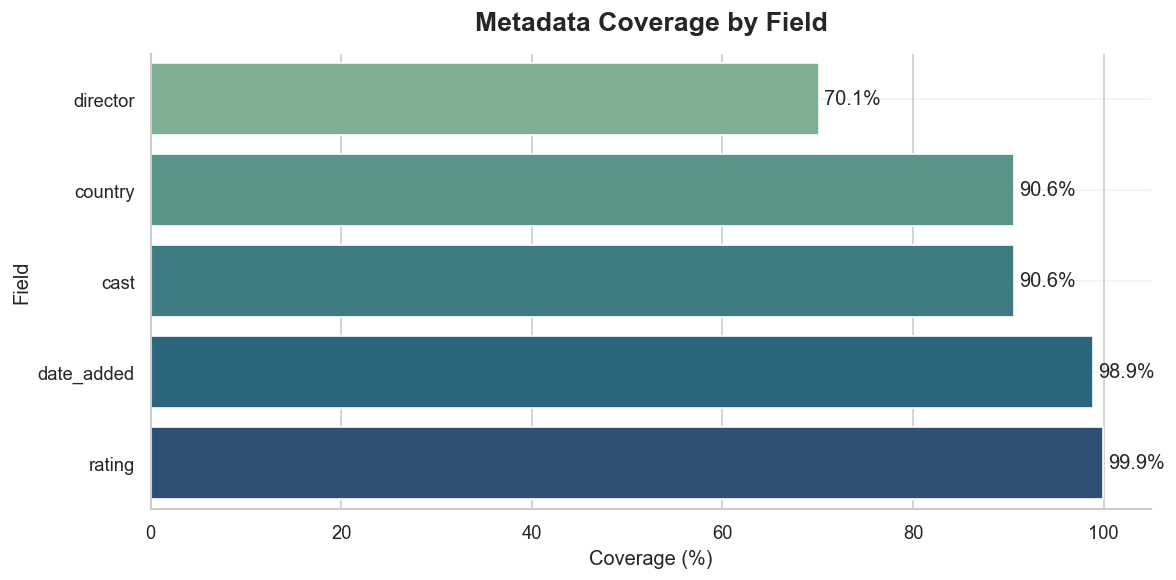

,field,coverage_pct
0,director,70.09
2,country,90.56
1,cast,90.63
4,date_added,98.89
3,rating,99.92


In [89]:
metadata_quality = pd.DataFrame({
    "field": ["director", "cast", "country", "rating", "date_added"],
    "coverage_pct": [
        netflix["has_director"].mean() * 100,
        netflix["has_cast"].mean() * 100,
        netflix["has_country"].mean() * 100,
        netflix["rating"].ne("Unknown Rating").mean() * 100,
        netflix["date_added"].notna().mean() * 100,
    ],
}).sort_values("coverage_pct")

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=metadata_quality, x="coverage_pct", y="field", palette="crest")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)
polish_chart("Metadata Coverage by Field", "Coverage (%)", "Field")
plt.xlim(0, 105)
plt.show()

display(metadata_quality.round(2))

In [90]:
weakest_metadata_field = metadata_quality.iloc[0]["field"]
weakest_metadata_pct = metadata_quality.iloc[0]["coverage_pct"]

display(Markdown(f'''
**Metadata Quality Insights**

- **{weakest_metadata_field}** has the lowest metadata coverage at **{weakest_metadata_pct:.1f}%**.
- Missing metadata can weaken search, recommendations, attribution, and regional reporting.

**Business implication:** Improving low-coverage metadata fields should be treated as a data-quality priority because it directly affects product discovery and analytics accuracy.
'''))


**Metadata Quality Insights**

- **director** has the lowest metadata coverage at **70.1%**.
- Missing metadata can weaken search, recommendations, attribution, and regional reporting.

**Business implication:** Improving low-coverage metadata fields should be treated as a data-quality priority because it directly affects product discovery and analytics accuracy.


## Executive Summary

In [91]:
executive_summary = f'''
### Executive Summary

Netflix's catalog in this dataset contains **{total_titles:,} titles**, with **{dominant_type}** making up the largest share at **{dominant_pct:.2f}%**. Catalog growth peaked in **{peak_year}**, when **{peak_year_count:,} titles** were added, and the strongest year-over-year growth was observed in **{strongest_growth_year}**.

From a portfolio perspective, **{top_country}** is the leading content-producing country, **{top_genre}** is the most common genre, and **{most_common_rating}** is the most frequent rating. The catalog's median movie runtime is **{movie_duration_stats.loc['50%']:.1f} minutes**, and the median content age when added is **{content_age_stats.loc['50%']:.1f} years**.

The analysis suggests three practical priorities:

1. Balance high-volume genres with underrepresented opportunity areas by country.
2. Use maturity and duration segments to strengthen audience-specific recommendations.
3. Improve metadata completeness, especially for the weakest field: **{weakest_metadata_field}**.
'''

display(Markdown(executive_summary))


### Executive Summary

Netflix's catalog in this dataset contains **8,807 titles**, with **Movie** making up the largest share at **69.62%**. Catalog growth peaked in **2019**, when **1,999 titles** were added, and the strongest year-over-year growth was observed in **2011**.

From a portfolio perspective, **United States** is the leading content-producing country, **International Movies** is the most common genre, and **TV-MA** is the most frequent rating. The catalog's median movie runtime is **98.0 minutes**, and the median content age when added is **1.0 years**.

The analysis suggests three practical priorities:

1. Balance high-volume genres with underrepresented opportunity areas by country.
2. Use maturity and duration segments to strengthen audience-specific recommendations.
3. Improve metadata completeness, especially for the weakest field: **director**.


## Insights and Conclusions

In [92]:
# Build final findings dynamically from the cleaned dataset
findings = []

findings.append(f"The Netflix catalog contains {total_titles:,} titles in this dataset.")
findings.append(f"{dominant_type} are the largest content type, representing {dominant_pct:.2f}% of the catalog.")
findings.append(f"The peak year for content additions was {peak_year}, with {peak_year_count:,} titles added.")
findings.append(f"{peak_month_name} was the most active month for adding content.")
findings.append(f"{top_country} is the leading listed country, appearing in {top_country_count:,} titles.")
findings.append(f"{top_genre} is the most frequent genre, appearing in {top_genre_count:,} titles.")
findings.append(f"{most_common_rating} is the most common content rating, with {most_common_rating_count:,} titles.")
findings.append(f"The average movie duration is approximately {avg_movie_duration:.1f} minutes.")
findings.append(f"The most common TV Show length is {most_common_seasons} season(s).")
findings.append(f"In {latest_year}, {latest_top_type} had the highest additions among content types.")

recommendations = [
    "Strengthen investment in high-performing genres while maintaining enough variety for discovery.",
    "Use country-level patterns to prioritize regional licensing, localization, and original production.",
    "Monitor the balance between Movies and TV Shows to support both browsing variety and subscriber retention.",
    "Use ratings distribution to improve family, teen, and mature-audience recommendation experiences.",
    "Promote frequent actors and directors through curated collections and talent-led campaigns.",
    "Investigate years with sharp catalog growth or decline to understand acquisition strategy changes.",
    "Use duration and season patterns to create viewing-time based recommendation rows.",
    "Improve metadata completeness for cast, director, and country fields to strengthen search and personalization.",
]

markdown_text = "### 10 Key Findings\n\n"
markdown_text += "\n".join([f"{i+1}. {finding}" for i, finding in enumerate(findings)])
markdown_text += "\n\n### Actionable Recommendations\n\n"
markdown_text += "\n".join([f"{i+1}. {rec}" for i, rec in enumerate(recommendations)])
markdown_text += (
    "\n\n### Summary of Trends\n\n"
    "Netflix's catalog can be understood through four major lenses: content type balance, "
    "time-based growth, geographic contribution, and genre/rating mix. Together, these "
    "trends show how Netflix has built a broad international catalog while balancing "
    "audience maturity levels, regional supply, and content formats."
)

display(Markdown(markdown_text))

### 10 Key Findings

1. The Netflix catalog contains 8,807 titles in this dataset.
2. Movie are the largest content type, representing 69.62% of the catalog.
3. The peak year for content additions was 2019, with 1,999 titles added.
4. July was the most active month for adding content.
5. United States is the leading listed country, appearing in 3,690 titles.
6. International Movies is the most frequent genre, appearing in 2,752 titles.
7. TV-MA is the most common content rating, with 3,207 titles.
8. The average movie duration is approximately 99.6 minutes.
9. The most common TV Show length is 1 season(s).
10. In 2021, Movie had the highest additions among content types.

### Actionable Recommendations

1. Strengthen investment in high-performing genres while maintaining enough variety for discovery.
2. Use country-level patterns to prioritize regional licensing, localization, and original production.
3. Monitor the balance between Movies and TV Shows to support both browsing variety and subscriber retention.
4. Use ratings distribution to improve family, teen, and mature-audience recommendation experiences.
5. Promote frequent actors and directors through curated collections and talent-led campaigns.
6. Investigate years with sharp catalog growth or decline to understand acquisition strategy changes.
7. Use duration and season patterns to create viewing-time based recommendation rows.
8. Improve metadata completeness for cast, director, and country fields to strengthen search and personalization.

### Summary of Trends

Netflix's catalog can be understood through four major lenses: content type balance, time-based growth, geographic contribution, and genre/rating mix. Together, these trends show how Netflix has built a broad international catalog while balancing audience maturity levels, regional supply, and content formats.